# 🔋 배터리 Capacity 예측 모델

중고 배터리 셀의 초기 측정 데이터(전압, AC 임피던스)로부터 실제 방전 용량(Capacity)을 예측합니다.

| Phase | 내용 | 목적 |
|-------|------|------|
| **Phase 1** | 데이터 탐색 (EDA) | 데이터 품질·분포·상관관계 파악 |
| **Phase 2** | 파생변수 생성 | 임피던스/전압 기반 파생 피처 |
| **Phase 3** | 전처리 및 피처 선택 | 이상치 제거, VIF 분석, 시나리오 확정 |
| **Phase 4** | 학습 데이터 구성 | Train/Test 분할, 스케일링 |
| **Phase 5** | 기본 모델 학습 | LR/SVR/RF/XGBoost/LightGBM 벤치마크 |
| **Phase 6** | Multi-AutoML 벤치마킹 | CatBoost/SVR/FLAML/AutoGluon 비교 |
| **Phase 7** | 모델 해석 (SHAP) | Feature Importance & SHAP 분석 |
| **Phase 8** | 최종 검증 및 결론 | 테스트 성능 확인, 시각화, 결론 |

In [1]:
import subprocess, sys

packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "scipy", "statsmodels", "scikit-learn",
    "xgboost", "lightgbm", "catboost",
    "flaml", "shap",
    "ipykernel", "jinja2"
]

failed = []
for pkg in packages:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        print(f"✅ {pkg}")
    except subprocess.CalledProcessError:
        print(f"⚠️ {pkg} 설치 실패")
        failed.append(pkg)

# ============================================================
# PyTorch CUDA 12.8 GPU 설치 (RTX 5070, Driver 576.88, CUDA 12.9)
# ============================================================
# 설치 성공 명령어 (터미널):
#   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128 --force-reinstall --no-cache-dir
#
# 주의: pip install ... -q 만으로는 CPU 버전이 캐시에서 설치될 수 있음
#       → --force-reinstall --no-cache-dir 필수
# 검증: torch 2.10.0+cu128, CUDA 12.8, GPU: NVIDIA GeForce RTX 5070
# ============================================================
print("\n📦 torch 설치 중 (CUDA 12.8 GPU)...")
try:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install",
         "torch", "torchvision",
         "--index-url", "https://download.pytorch.org/whl/cu128",
         "--force-reinstall", "--no-cache-dir", "-q"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
    import torch
    if torch.cuda.is_available():
        print(f"✅ torch {torch.__version__} (CUDA {torch.version.cuda}, GPU: {torch.cuda.get_device_name(0)})")
    else:
        print(f"✅ torch {torch.__version__} (⚠️ CUDA 미감지 — CPU 모드)")
except subprocess.CalledProcessError:
    print("⚠️ torch GPU 설치 실패 → CPU 버전 시도...")
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install",
             "torch", "torchvision",
             "--index-url", "https://download.pytorch.org/whl/cpu", "-q"],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        print("✅ torch (CPU fallback)")
    except subprocess.CalledProcessError:
        print("⚠️ torch 설치 실패")
        failed.append("torch")

# autogluon.tabular: pip 실패 시 conda-forge로 설치
print("\n📦 autogluon.tabular 설치 중...")
try:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "autogluon.tabular", "-q"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
    print("✅ autogluon.tabular (pip)")
except subprocess.CalledProcessError:
    print("  pip 실패 → conda-forge로 시도...")
    try:
        subprocess.check_call(
            ["conda", "install", "-c", "conda-forge", "autogluon.tabular", "-y", "-q"],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        print("✅ autogluon.tabular (conda-forge)")
    except (subprocess.CalledProcessError, FileNotFoundError):
        print("⚠️ autogluon.tabular 설치 실패")
        print("  → 수동 설치: conda install -c conda-forge autogluon.tabular")
        failed.append("autogluon.tabular")

if failed:
    print(f"\n⚠️ 실패 패키지: {failed}")
else:
    print("\n🎉 모든 라이브러리 설치 완료!")

✅ pandas
✅ numpy
✅ matplotlib
✅ seaborn
✅ scipy
✅ statsmodels
✅ scikit-learn
✅ xgboost
✅ lightgbm
✅ catboost
✅ flaml
✅ shap
✅ ipykernel
✅ jinja2

📦 torch 설치 중 (CUDA 12.8 GPU)...
✅ torch 2.10.0+cu128 (CUDA 12.8, GPU: NVIDIA GeForce RTX 5070)

📦 autogluon.tabular 설치 중...
✅ autogluon.tabular (pip)

🎉 모든 라이브러리 설치 완료!


---
# Phase 1: 데이터 탐색 및 분석 (EDA)

In [2]:
# 1-0. 라이브러리 로드 및 환경 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

COLORS = sns.color_palette('husl', 10)
print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


### 1-1. 데이터 로드 및 컬럼 정리

In [3]:
# 원본 데이터 로드
raw = pd.read_csv(r'./data.csv')

# 컬럼 이름 재정의
new_columns = [
    'cell_id', 'initial_label', 'initial_voltage', 'initial_impedance',
    'v42_label', 'v42_voltage', 'v42_impedance',
    'v25_label', 'v25_voltage', 'v25_impedance',
    'v36_label', 'v36_voltage', 'v36_empty', 'v36_impedance',
    'capacity'
]
raw.columns = new_columns

# 라벨/빈 컬럼 제거
drop_cols = ['initial_label', 'v42_label', 'v25_label', 'v36_label', 'v36_empty']
df = raw.drop(columns=drop_cols)

# 수치형 변환
numeric_cols = [c for c in df.columns if c != 'cell_id']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 피처/타겟 정의
FEATURES = [c for c in df.columns if c not in ['cell_id', 'capacity']]
TARGET = 'capacity'

print(f'데이터 Shape: {df.shape}')
print(f'피처 목록: {FEATURES}')
print(f'타겟: {TARGET}')
df.head()

데이터 Shape: (1040, 10)
피처 목록: ['initial_voltage', 'initial_impedance', 'v42_voltage', 'v42_impedance', 'v25_voltage', 'v25_impedance', 'v36_voltage', 'v36_impedance']
타겟: capacity


,cell_id,initial_voltage,initial_impedance,v42_voltage,v42_impedance,v25_voltage,v25_impedance,v36_voltage,v36_impedance,capacity
0,BS-LSBAT-S240629-0001,3.456,11.42,4.178,10.56,2.977,10.97,3.59,10.85,4.9762
1,BS-LSBAT-S240629-0002,3.455,11.55,4.178,10.31,2.969,11.12,3.59,11.08,4.9986
2,BS-LSBAT-S240629-0003,3.456,11.61,4.177,10.41,2.974,10.97,3.59,11.08,5.0045
3,BS-LSBAT-S240629-0004,3.456,11.51,4.178,10.44,2.970,10.83,3.59,10.79,5.0007
4,BS-LSBAT-S240629-0005,3.457,10.93,4.178,10.39,2.961,10.55,3.59,10.62,5.0119


### 1-2. 기본 통계 분석

In [4]:
# 기본 통계 + 결측치 확인
stats_df = df[numeric_cols].describe().T
stats_df['missing'] = df[numeric_cols].isnull().sum()
stats_df['missing_pct'] = (stats_df['missing'] / len(df) * 100).round(2)
stats_df['skewness'] = df[numeric_cols].skew()
stats_df['kurtosis'] = df[numeric_cols].kurtosis()

print('📊 기본 통계 요약')
stats_df.style.background_gradient(cmap='YlOrRd', subset=['std', 'missing_pct'])

📊 기본 통계 요약


,count,mean,std,min,25%,50%,75%,max,missing,missing_pct,skewness,kurtosis
initial_voltage,1040.000000,3.457123,0.001822,3.450000,3.456000,3.456000,3.460000,3.465000,0,0.000000,0.827596,0.325755
initial_impedance,1040.000000,11.387904,0.284824,10.660000,11.170000,11.400000,11.610000,12.250000,0,0.000000,-0.055497,-0.563862
v42_voltage,1040.000000,4.178036,0.002607,4.170000,4.177000,4.178000,4.179000,4.190000,0,0.000000,1.311139,8.379195
v42_impedance,1040.000000,10.707442,0.248826,10.170000,10.550000,10.670000,10.792500,11.650000,0,0.000000,1.136152,1.555157
v25_voltage,1040.000000,2.947957,0.022794,2.894000,2.934000,2.947000,2.960000,3.121000,0,0.000000,1.632284,9.387147
v25_impedance,1040.000000,10.996490,0.240566,10.310000,10.820000,10.970000,11.160000,11.860000,0,0.000000,0.318020,-0.285074
v36_voltage,1040.000000,3.589475,0.061999,3.560000,3.587000,3.587000,3.588000,5.586000,0,0.000000,32.203014,1038.024116
v36_impedance,1040.000000,11.776912,31.818556,10.000000,10.530000,10.670000,10.840000,1032.000000,0,0.000000,31.817029,1020.259686
capacity,1040.000000,5.026004,0.033003,4.791900,5.014850,5.031250,5.044400,5.097400,0,0.000000,-2.829875,12.883408


### 1-3. 분포 시각화 (히스토그램 + KDE)

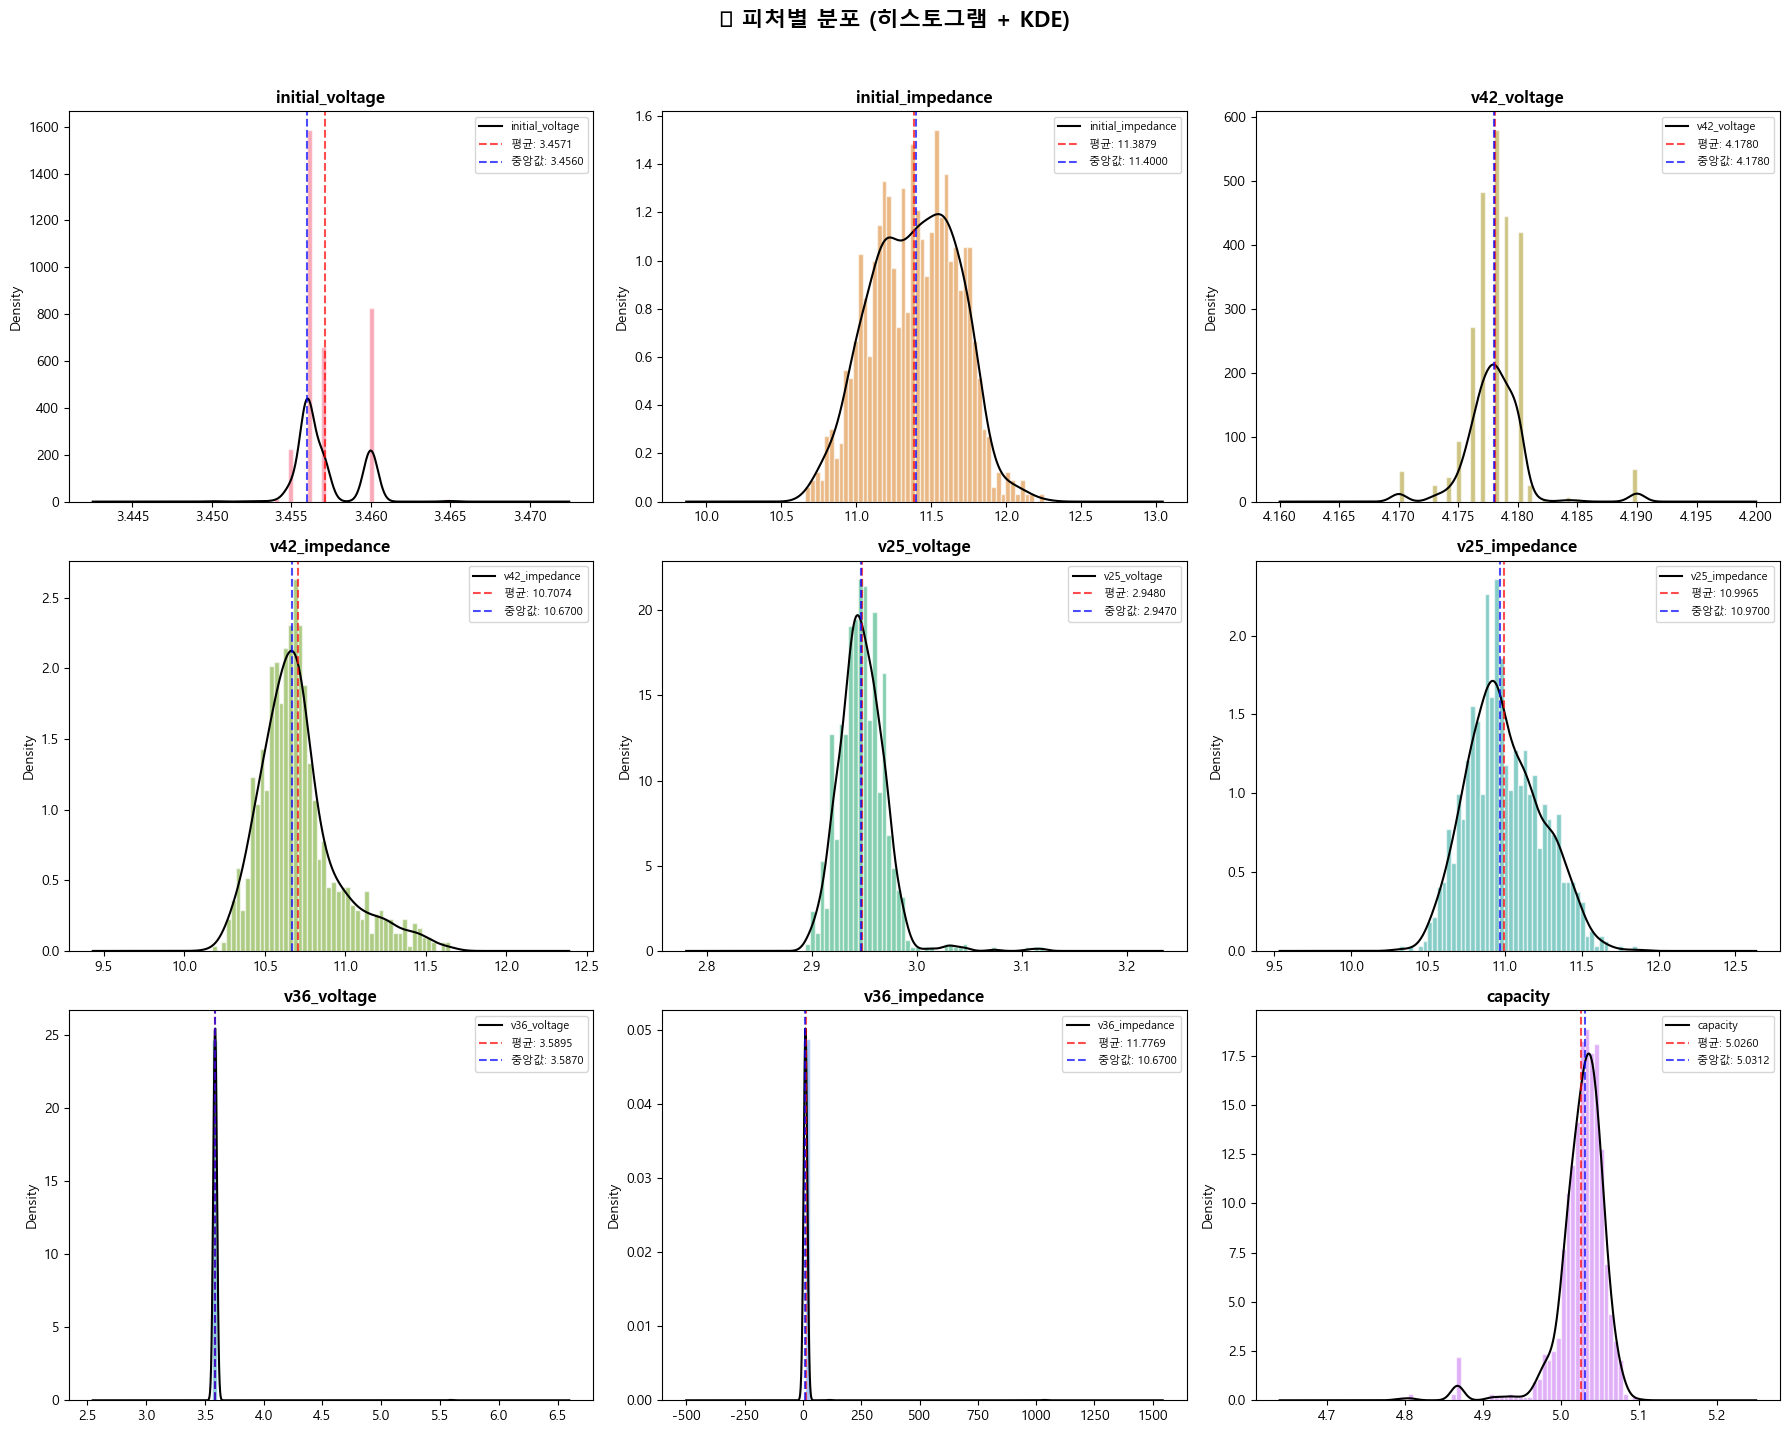

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, alpha=0.6, color=COLORS[i], edgecolor='white', density=True)
    data.plot.kde(ax=ax, color='black', linewidth=1.5)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.axvline(data.mean(), color='red', linestyle='--', alpha=0.7, label=f'평균: {data.mean():.4f}')
    ax.axvline(data.median(), color='blue', linestyle='--', alpha=0.7, label=f'중앙값: {data.median():.4f}')
    ax.legend(fontsize=8)

plt.suptitle('📊 피처별 분포 (히스토그램 + KDE)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1-4. 박스플롯 (이상치 확인)

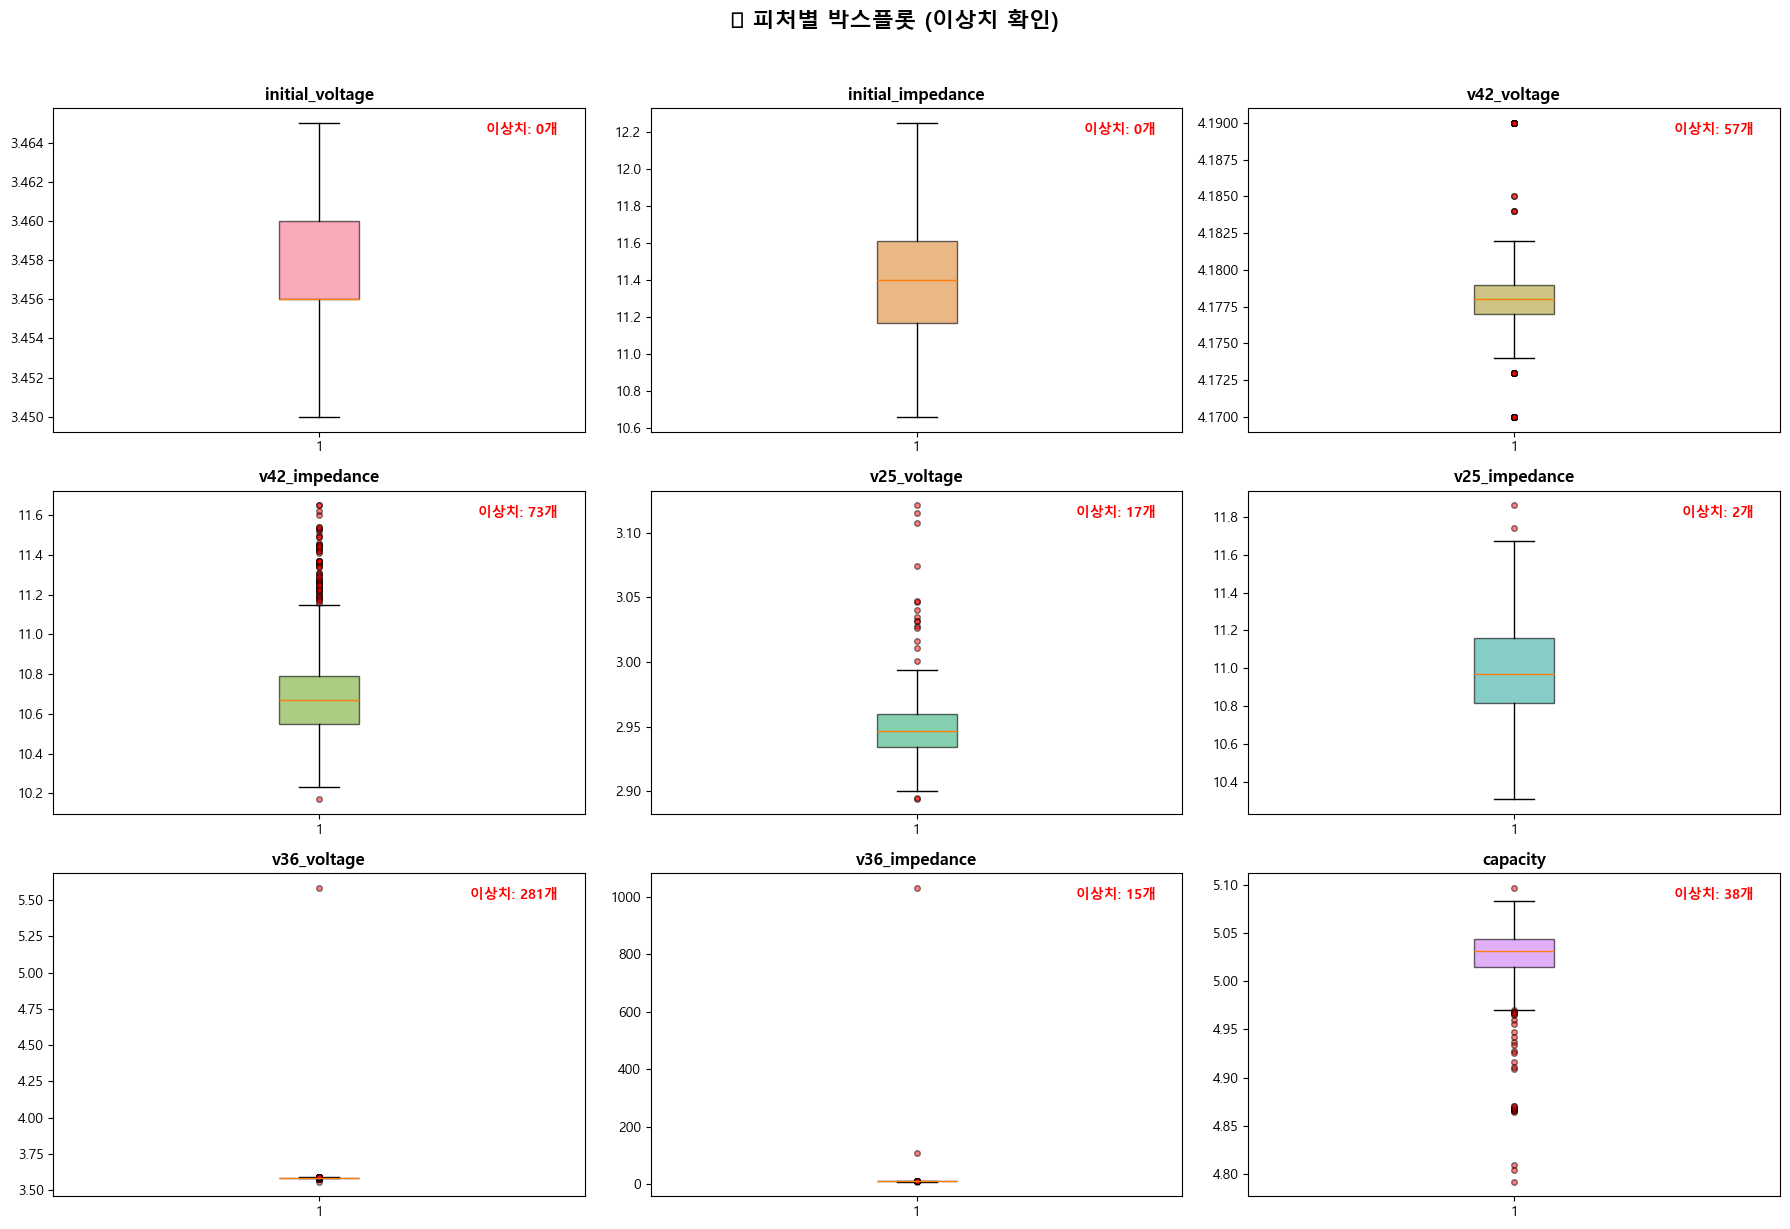

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    bp = ax.boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=COLORS[i], alpha=0.6),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    ax.text(0.95, 0.95, f'이상치: {outliers}개', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='red', fontweight='bold')

plt.suptitle('📦 피처별 박스플롯 (이상치 확인)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1-5. 상관분석 (Pearson / Spearman)

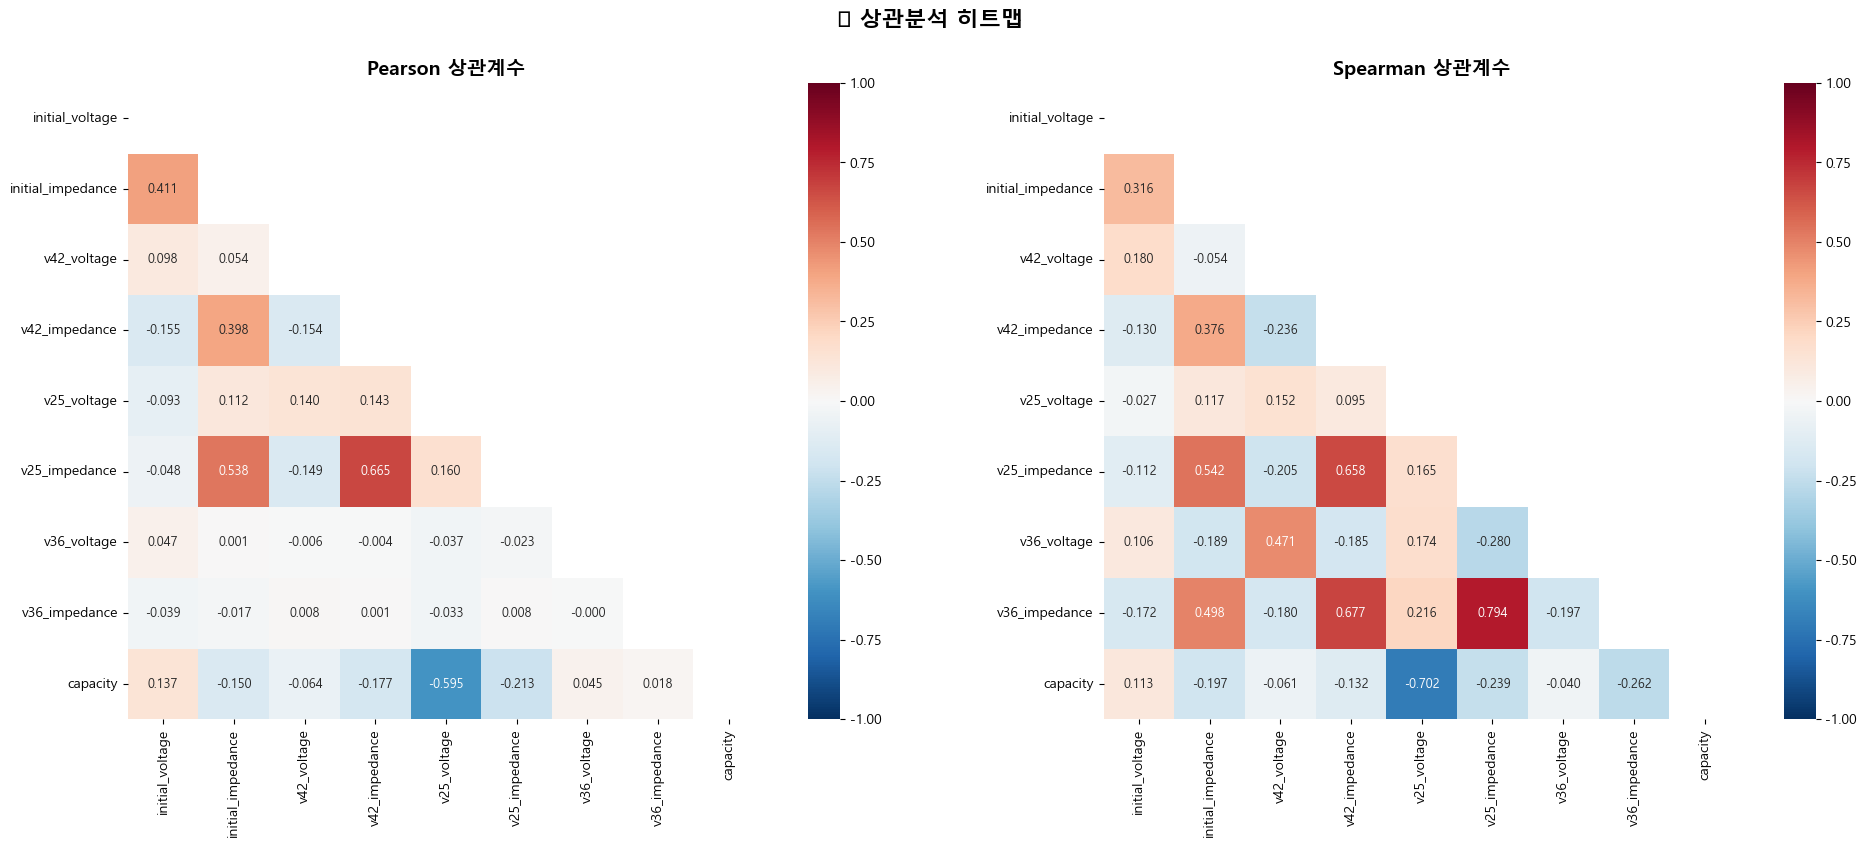

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Pearson
pearson_corr = df[numeric_cols].corr(method='pearson')
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=axes[0], vmin=-1, vmax=1, square=True, annot_kws={'size': 9})
axes[0].set_title('Pearson 상관계수', fontsize=14, fontweight='bold')

# Spearman
spearman_corr = df[numeric_cols].corr(method='spearman')
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=axes[1], vmin=-1, vmax=1, square=True, annot_kws={'size': 9})
axes[1].set_title('Spearman 상관계수', fontsize=14, fontweight='bold')

plt.suptitle('📈 상관분석 히트맵', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Capacity와의 상관계수 정리
corr_with_target = pd.DataFrame({
    'Pearson': pearson_corr[TARGET].drop(TARGET),
    'Spearman': spearman_corr[TARGET].drop(TARGET),
    '|Pearson|': pearson_corr[TARGET].drop(TARGET).abs(),
    '|Spearman|': spearman_corr[TARGET].drop(TARGET).abs()
}).sort_values('|Pearson|', ascending=False)

print('🎯 Capacity와의 상관계수 (절대값 내림차순)')
corr_with_target.style.background_gradient(cmap='YlOrRd', subset=['|Pearson|', '|Spearman|'])

🎯 Capacity와의 상관계수 (절대값 내림차순)


,Pearson,Spearman,|Pearson|,|Spearman|
v25_voltage,-0.595221,-0.702368,0.595221,0.702368
v25_impedance,-0.213042,-0.238592,0.213042,0.238592
v42_impedance,-0.177324,-0.131840,0.177324,0.131840
initial_impedance,-0.149917,-0.196598,0.149917,0.196598
initial_voltage,0.136540,0.113338,0.136540,0.113338
v42_voltage,-0.064421,-0.061185,0.064421,0.061185
v36_voltage,0.045443,-0.039960,0.045443,0.039960
v36_impedance,0.017784,-0.262349,0.017784,0.262349


### 1-6. 피처 vs Capacity 산점도

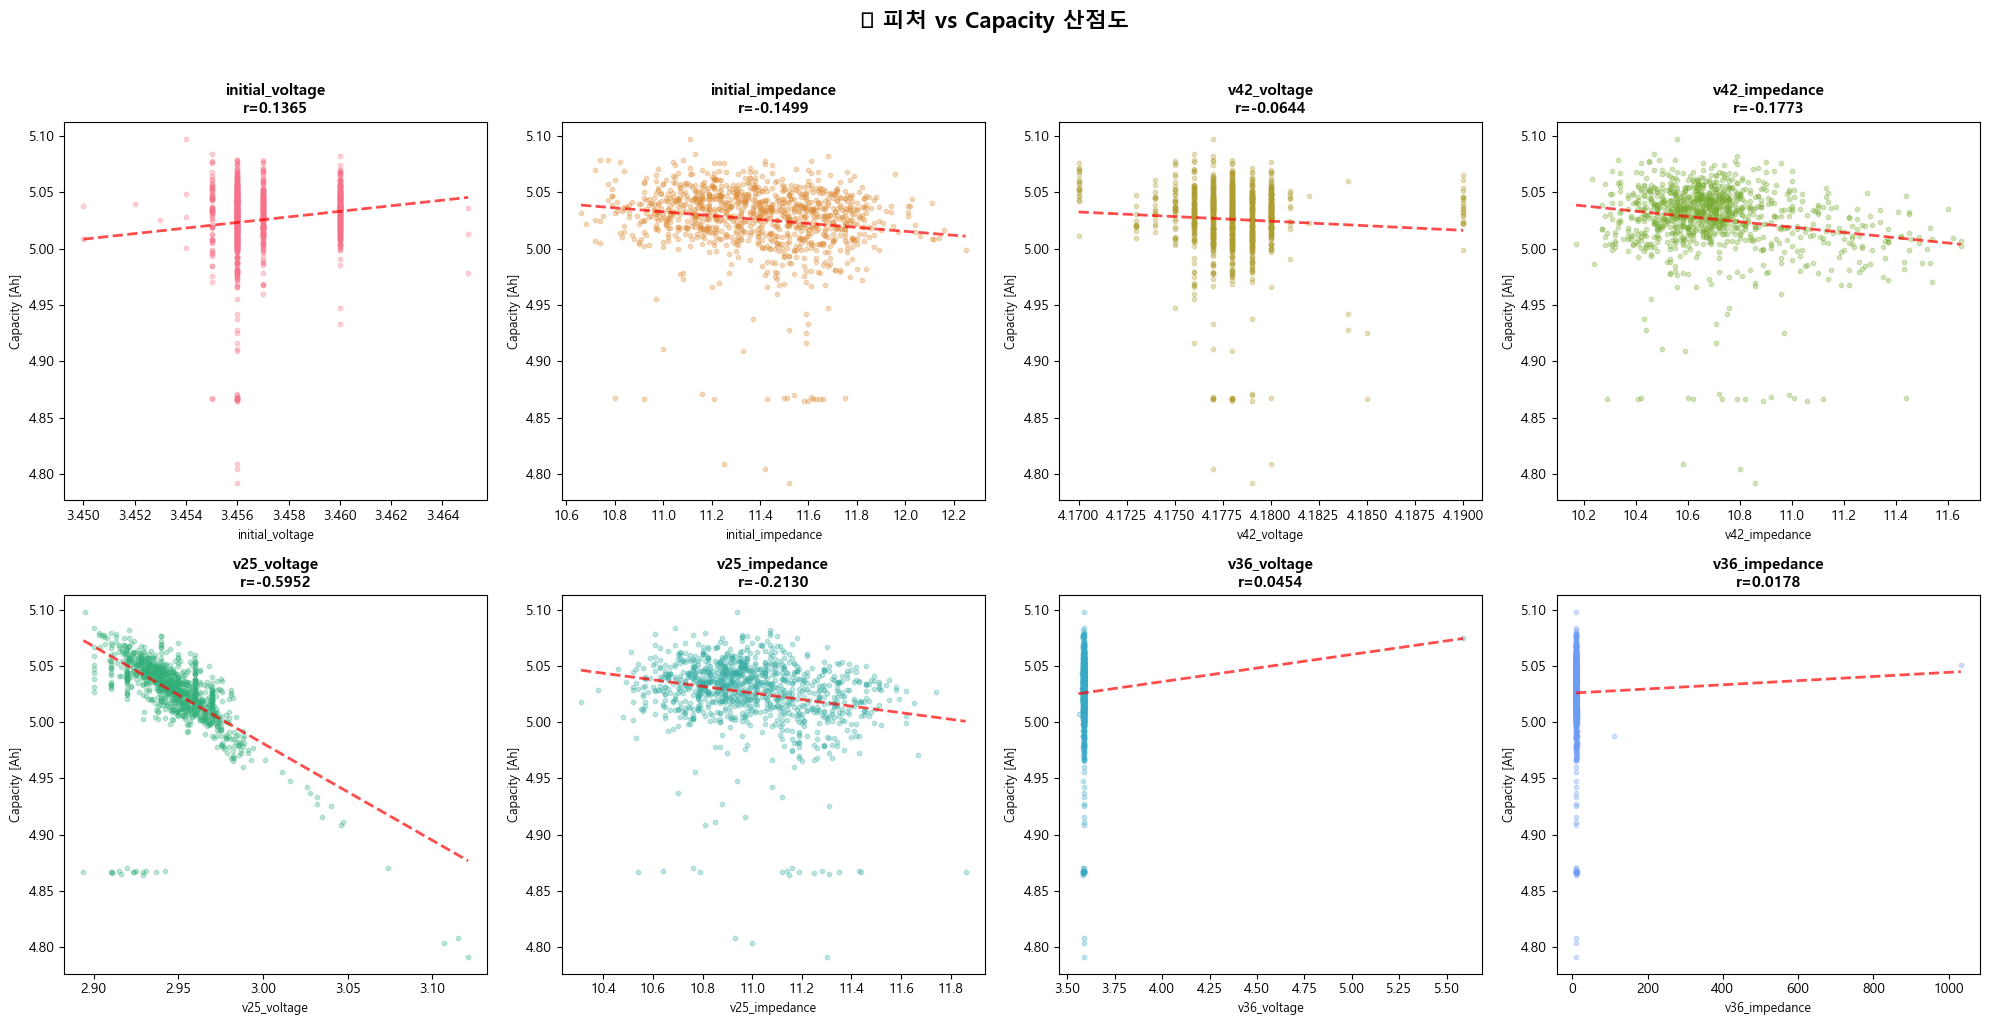

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    ax = axes[i]
    ax.scatter(df[col], df[TARGET], alpha=0.3, s=10, color=COLORS[i])
    valid = df[[col, TARGET]].dropna()
    z = np.polyfit(valid[col], valid[TARGET], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(valid[col])
    ax.plot(x_sorted, p(x_sorted), 'r--', linewidth=2, alpha=0.7)
    r = valid[col].corr(valid[TARGET])
    ax.set_title(f'{col}\nr={r:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Capacity [Ah]', fontsize=9)

plt.suptitle('🔍 피처 vs Capacity 산점도', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1-7. 이상치 탐지 (IQR + Z-score)

In [10]:
def detect_outliers(df, columns):
    """IQR 및 Z-score 기반 이상치 탐지"""
    results = []
    for col in columns:
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        iqr_lower = Q1 - 1.5 * IQR
        iqr_upper = Q3 + 1.5 * IQR
        iqr_outliers = ((data < iqr_lower) | (data > iqr_upper)).sum()
        z_scores = np.abs(stats.zscore(data))
        z_outliers = (z_scores > 3).sum()
        results.append({
            '피처': col,
            'IQR_하한': round(iqr_lower, 4), 'IQR_상한': round(iqr_upper, 4),
            'IQR_이상치수': iqr_outliers,
            'IQR_이상치비율(%)': round(iqr_outliers / len(data) * 100, 2),
            'Z-score_이상치수(|z|>3)': z_outliers,
            'Z-score_비율(%)': round(z_outliers / len(data) * 100, 2)
        })
    return pd.DataFrame(results).set_index('피처')

outlier_report = detect_outliers(df, numeric_cols)
print('🚨 이상치 탐지 결과')
outlier_report.style.background_gradient(cmap='Reds', subset=['IQR_이상치수', 'Z-score_이상치수(|z|>3)'])

🚨 이상치 탐지 결과


,IQR_하한,IQR_상한,IQR_이상치수,IQR_이상치비율(%),Z-score_이상치수(|z|>3),Z-score_비율(%)
피처,,,,,,
initial_voltage,3.450000,3.466000,0,0.000000,5,0.480000
initial_impedance,10.510000,12.270000,0,0.000000,1,0.100000
v42_voltage,4.174000,4.182000,57,5.480000,41,3.940000
v42_impedance,10.186300,11.156200,73,7.020000,13,1.250000
v25_voltage,2.895000,2.999000,17,1.630000,12,1.150000
v25_impedance,10.310000,11.670000,2,0.190000,2,0.190000
v36_voltage,3.585500,3.589500,281,27.020000,1,0.100000
v36_impedance,10.065000,11.305000,15,1.440000,2,0.190000
capacity,4.970500,5.088700,38,3.650000,23,2.210000


In [11]:
# 이상치 셀 집계
all_outlier_idx = set()
for col in numeric_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    all_outlier_idx.update(df[mask].index.tolist())

print(f'📌 하나 이상의 피처에서 이상치인 셀 수: {len(all_outlier_idx)}개 / 전체 {len(df)}개')
print(f'   이상치 비율: {len(all_outlier_idx)/len(df)*100:.1f}%')

📌 하나 이상의 피처에서 이상치인 셀 수: 379개 / 전체 1040개
   이상치 비율: 36.4%


### 1-8. 피처 그룹별 패턴 분석

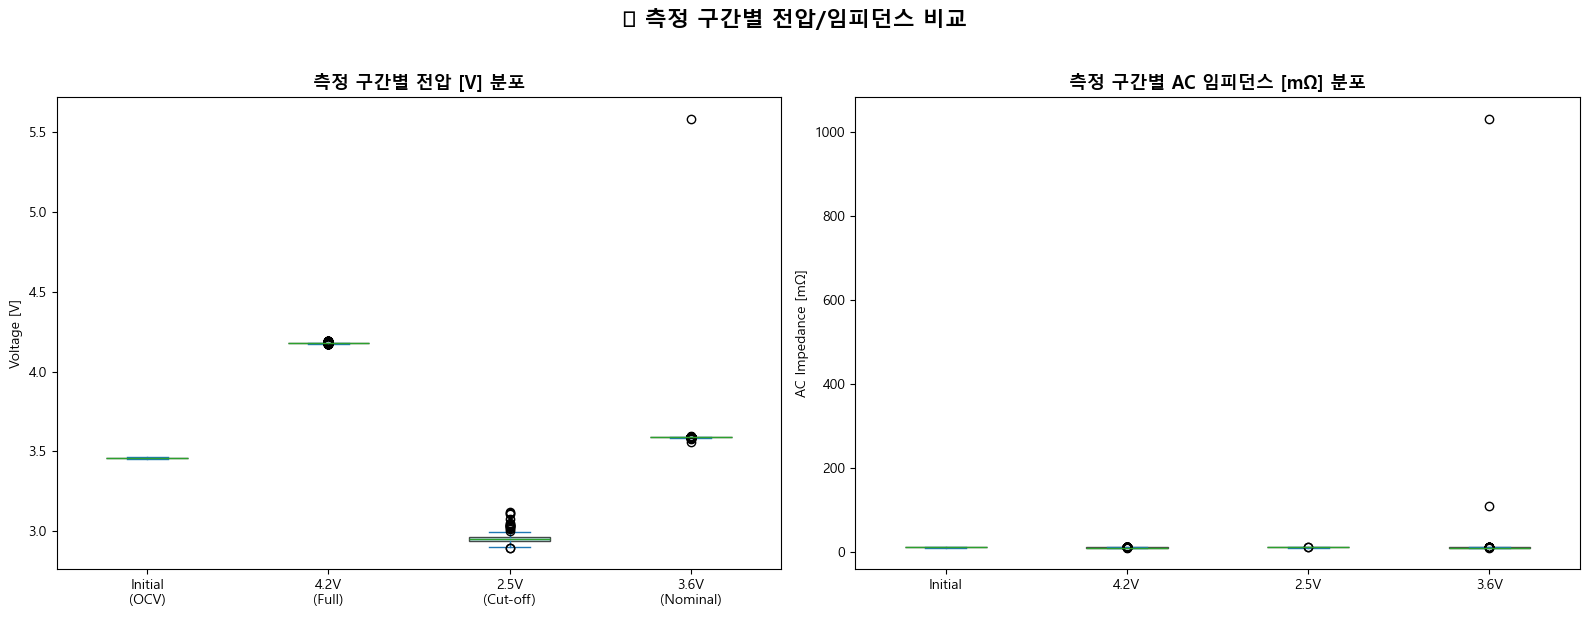

In [12]:
voltage_cols = ['initial_voltage', 'v42_voltage', 'v25_voltage', 'v36_voltage']
impedance_cols = ['initial_impedance', 'v42_impedance', 'v25_impedance', 'v36_impedance']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df[voltage_cols].plot.box(ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0].set_title('측정 구간별 전압 [V] 분포', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Voltage [V]')
axes[0].set_xticklabels(['Initial\n(OCV)', '4.2V\n(Full)', '2.5V\n(Cut-off)', '3.6V\n(Nominal)'])

df[impedance_cols].plot.box(ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='lightyellow', alpha=0.7))
axes[1].set_title('측정 구간별 AC 임피던스 [mΩ] 분포', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AC Impedance [mΩ]')
axes[1].set_xticklabels(['Initial', '4.2V', '2.5V', '3.6V'])

plt.suptitle('⚡ 측정 구간별 전압/임피던스 비교', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1-9. EDA 요약

In [13]:
print('=' * 70)
print('📋 Phase 1 EDA 요약 리포트')
print('=' * 70)
print(f'\n📊 데이터 기본 정보')
print(f'   Total Samples: {len(df)}')
print(f'   Features: {len(FEATURES)}개')
print(f'   결측치: {df[numeric_cols].isnull().sum().sum()}개')

cap_stats = df[TARGET].describe()
print(f'\n🎯 Capacity (타겟) 분포')
print(f'   평균: {cap_stats["mean"]:.4f} Ah')
print(f'   표준편차: {cap_stats["std"]:.4f} Ah')
print(f'   범위: {cap_stats["min"]:.4f} ~ {cap_stats["max"]:.4f} Ah')

print(f'\n📈 Capacity와 상관계수 TOP-5 (Pearson)')
top5 = corr_with_target.sort_values('|Pearson|', ascending=False).head(5)
for feat, row in top5.iterrows():
    print(f'   {feat}: r={row["Pearson"]:.4f}')

print(f'\n🚨 이상치 현황')
print(f'   이상치 포함 셀: {len(all_outlier_idx)}개 ({len(all_outlier_idx)/len(df)*100:.1f}%)')
print(f'\n✅ Phase 1 완료 → Phase 2 (파생변수 생성)으로 진행')
print('=' * 70)

📋 Phase 1 EDA 요약 리포트

📊 데이터 기본 정보
   Total Samples: 1040
   Features: 8개
   결측치: 0개

🎯 Capacity (타겟) 분포
   평균: 5.0260 Ah
   표준편차: 0.0330 Ah
   범위: 4.7919 ~ 5.0974 Ah

📈 Capacity와 상관계수 TOP-5 (Pearson)
   v25_voltage: r=-0.5952
   v25_impedance: r=-0.2130
   v42_impedance: r=-0.1773
   initial_impedance: r=-0.1499
   initial_voltage: r=0.1365

🚨 이상치 현황
   이상치 포함 셀: 379개 (36.4%)

✅ Phase 1 완료 → Phase 2 (파생변수 생성)으로 진행


---
# Phase 2: 파생변수 생성 (Feature Engineering)

배터리 특성을 반영한 파생변수를 생성합니다.
- **임피던스 기반**: 구간 간 내부저항 변화량/비율
- **전압 기반**: 충방전 전압차, 전압 강하폭
- **복합**: 전압×임피던스 교호작용

### 2-1. 임피던스 기반 파생변수

In [14]:
z_initial = 'initial_impedance'
z_42 = 'v42_impedance'
z_25 = 'v25_impedance'
z_36 = 'v36_impedance'

df['impedance_delta_42'] = df[z_42] - df[z_initial]
df['impedance_delta_25'] = df[z_25] - df[z_initial]
df['impedance_delta_36'] = df[z_36] - df[z_initial]
df['impedance_ratio_42'] = df[z_42] / df[z_initial]
df['impedance_ratio_25'] = df[z_25] / df[z_initial]
df['impedance_range'] = df[impedance_cols].max(axis=1) - df[impedance_cols].min(axis=1)
df['impedance_mean'] = df[impedance_cols].mean(axis=1)
df['impedance_std'] = df[impedance_cols].std(axis=1)

impedance_derived = ['impedance_delta_42', 'impedance_delta_25', 'impedance_delta_36',
                     'impedance_ratio_42', 'impedance_ratio_25',
                     'impedance_range', 'impedance_mean', 'impedance_std']

print(f'🔧 임피던스 기반 파생변수 {len(impedance_derived)}개 생성 완료')
df[impedance_derived].describe().T.style.format('{:.4f}')

🔧 임피던스 기반 파생변수 8개 생성 완료


,count,mean,std,min,25%,50%,75%,max
impedance_delta_42,1040.0000,-0.6805,0.2943,-1.7500,-0.8800,-0.6500,-0.4700,0.2300
impedance_delta_25,1040.0000,-0.3914,0.2554,-1.2700,-0.5400,-0.3600,-0.2300,0.7300
impedance_delta_36,1040.0000,0.3890,31.8248,-1.7900,-0.8500,-0.6600,-0.5100,1020.8200
impedance_ratio_42,1040.0000,0.9406,0.0247,0.8556,0.9235,0.9424,0.9583,1.0207
impedance_ratio_25,1040.0000,0.9659,0.0218,0.8931,0.9530,0.9688,0.9800,1.0680
impedance_range,1040.0000,1.8387,31.7942,0.2000,0.5600,0.7200,0.9400,1021.4100
impedance_mean,1040.0000,11.2172,7.9555,10.3925,10.8075,10.9300,11.0750,266.1850
impedance_std,1040.0000,0.8817,15.8932,0.0877,0.2568,0.3241,0.4234,510.5434


### 2-2. 전압 기반 파생변수

In [15]:
v_initial = 'initial_voltage'
v_42 = 'v42_voltage'
v_25 = 'v25_voltage'
v_36 = 'v36_voltage'

df['voltage_delta_initial_42'] = df[v_42] - df[v_initial]
df['voltage_delta_42_25'] = df[v_42] - df[v_25]
df['voltage_delta_42_36'] = df[v_42] - df[v_36]
df['voltage_sag'] = df[v_initial] - df[v_25]

NOMINAL_VOLTAGE = 3.6
df['ocv_deviation'] = df[v_initial] - NOMINAL_VOLTAGE

voltage_derived = ['voltage_delta_initial_42', 'voltage_delta_42_25', 'voltage_delta_42_36',
                   'voltage_sag', 'ocv_deviation']

print(f'🔧 전압 기반 파생변수 {len(voltage_derived)}개 생성 완료')
df[voltage_derived].describe().T.style.format('{:.4f}')

🔧 전압 기반 파생변수 5개 생성 완료


,count,mean,std,min,25%,50%,75%,max
voltage_delta_initial_42,1040.0000,0.7209,0.0030,0.7100,0.7200,0.7210,0.7230,0.7400
voltage_delta_42_25,1040.0000,1.2301,0.0226,1.0580,1.2180,1.2300,1.2440,1.2840
voltage_delta_42_36,1040.0000,0.5886,0.0621,-1.4090,0.5900,0.5900,0.5910,0.6180
voltage_sag,1040.0000,0.5092,0.0230,0.3350,0.4970,0.5110,0.5230,0.5610
ocv_deviation,1040.0000,-0.1429,0.0018,-0.1500,-0.1440,-0.1440,-0.1400,-0.1350


### 2-3. 복합 파생변수

In [16]:
df['impedance_voltage_product'] = df[z_initial] * df[v_initial]
df['power_loss_indicator'] = df[z_42] * (df[v_42] - df[v_25])
df['health_index'] = df[v_42] / df[z_42]

composite_derived = ['impedance_voltage_product', 'power_loss_indicator', 'health_index']

print(f'🔧 복합 파생변수 {len(composite_derived)}개 생성 완료')
df[composite_derived].describe().T.style.format('{:.4f}')

🔧 복합 파생변수 3개 생성 완료


,count,mean,std,min,25%,50%,75%,max
impedance_voltage_product,1040.0000,39.3696,0.9935,36.8410,38.6147,39.4039,40.1271,42.3850
power_loss_indicator,1040.0000,13.1701,0.3565,11.2677,12.9590,13.1544,13.3755,14.5276
health_index,1040.0000,0.3904,0.0089,0.3585,0.3869,0.3916,0.3961,0.4110


### 2-4. 파생변수 요약 및 Capacity 상관 분석

In [17]:
ALL_DERIVED = impedance_derived + voltage_derived + composite_derived

print('=' * 70)
print(f'Phase 2 파생변수 총 {len(ALL_DERIVED)}개 생성')
print(f'  - 임피던스 기반: {len(impedance_derived)}개')
print(f'  - 전압 기반: {len(voltage_derived)}개')
print(f'  - 복합: {len(composite_derived)}개')
print('=' * 70)

print(f'\n📈 파생변수 vs Capacity 상관계수 (Pearson)')
derived_corr = df[ALL_DERIVED + [TARGET]].corr()[TARGET].drop(TARGET)
derived_corr_sorted = derived_corr.abs().sort_values(ascending=False)

for feat in derived_corr_sorted.index:
    r = derived_corr[feat]
    abs_r = abs(r)
    strength = '🟢 강함' if abs_r > 0.5 else ('🟡 보통' if abs_r > 0.3 else '🔴 약함')
    print(f'   {feat:35s}: r={r:+.4f}  {strength}')

FEATURES_EXTENDED = FEATURES + ALL_DERIVED
print(f'\n🔑 확장 피처 수: {len(FEATURES_EXTENDED)}개 (원본 {len(FEATURES)} + 파생 {len(ALL_DERIVED)})')

Phase 2 파생변수 총 16개 생성
  - 임피던스 기반: 8개
  - 전압 기반: 5개
  - 복합: 3개

📈 파생변수 vs Capacity 상관계수 (Pearson)
   voltage_sag                        : r=+0.5998  🟢 강함
   voltage_delta_42_25                : r=+0.5935  🟢 강함
   power_loss_indicator               : r=+0.2504  🔴 약함
   health_index                       : r=+0.1708  🔴 약함
   impedance_voltage_product          : r=-0.1457  🔴 약함
   voltage_delta_initial_42           : r=-0.1375  🔴 약함
   ocv_deviation                      : r=+0.1365  🔴 약함
   voltage_delta_42_36                : r=-0.0481  🔴 약함
   impedance_ratio_25                 : r=-0.0369  🔴 약함
   impedance_delta_25                 : r=-0.0335  🔴 약함
   impedance_std                      : r=+0.0198  🔴 약함
   impedance_range                    : r=+0.0198  🔴 약함
   impedance_delta_36                 : r=+0.0191  🔴 약함
   impedance_mean                     : r=+0.0134  🔴 약함
   impedance_ratio_42                 : r=-0.0095  🔴 약함
   impedance_delta_42                 : r=-0.0048  🔴 약함

🔑 확장 

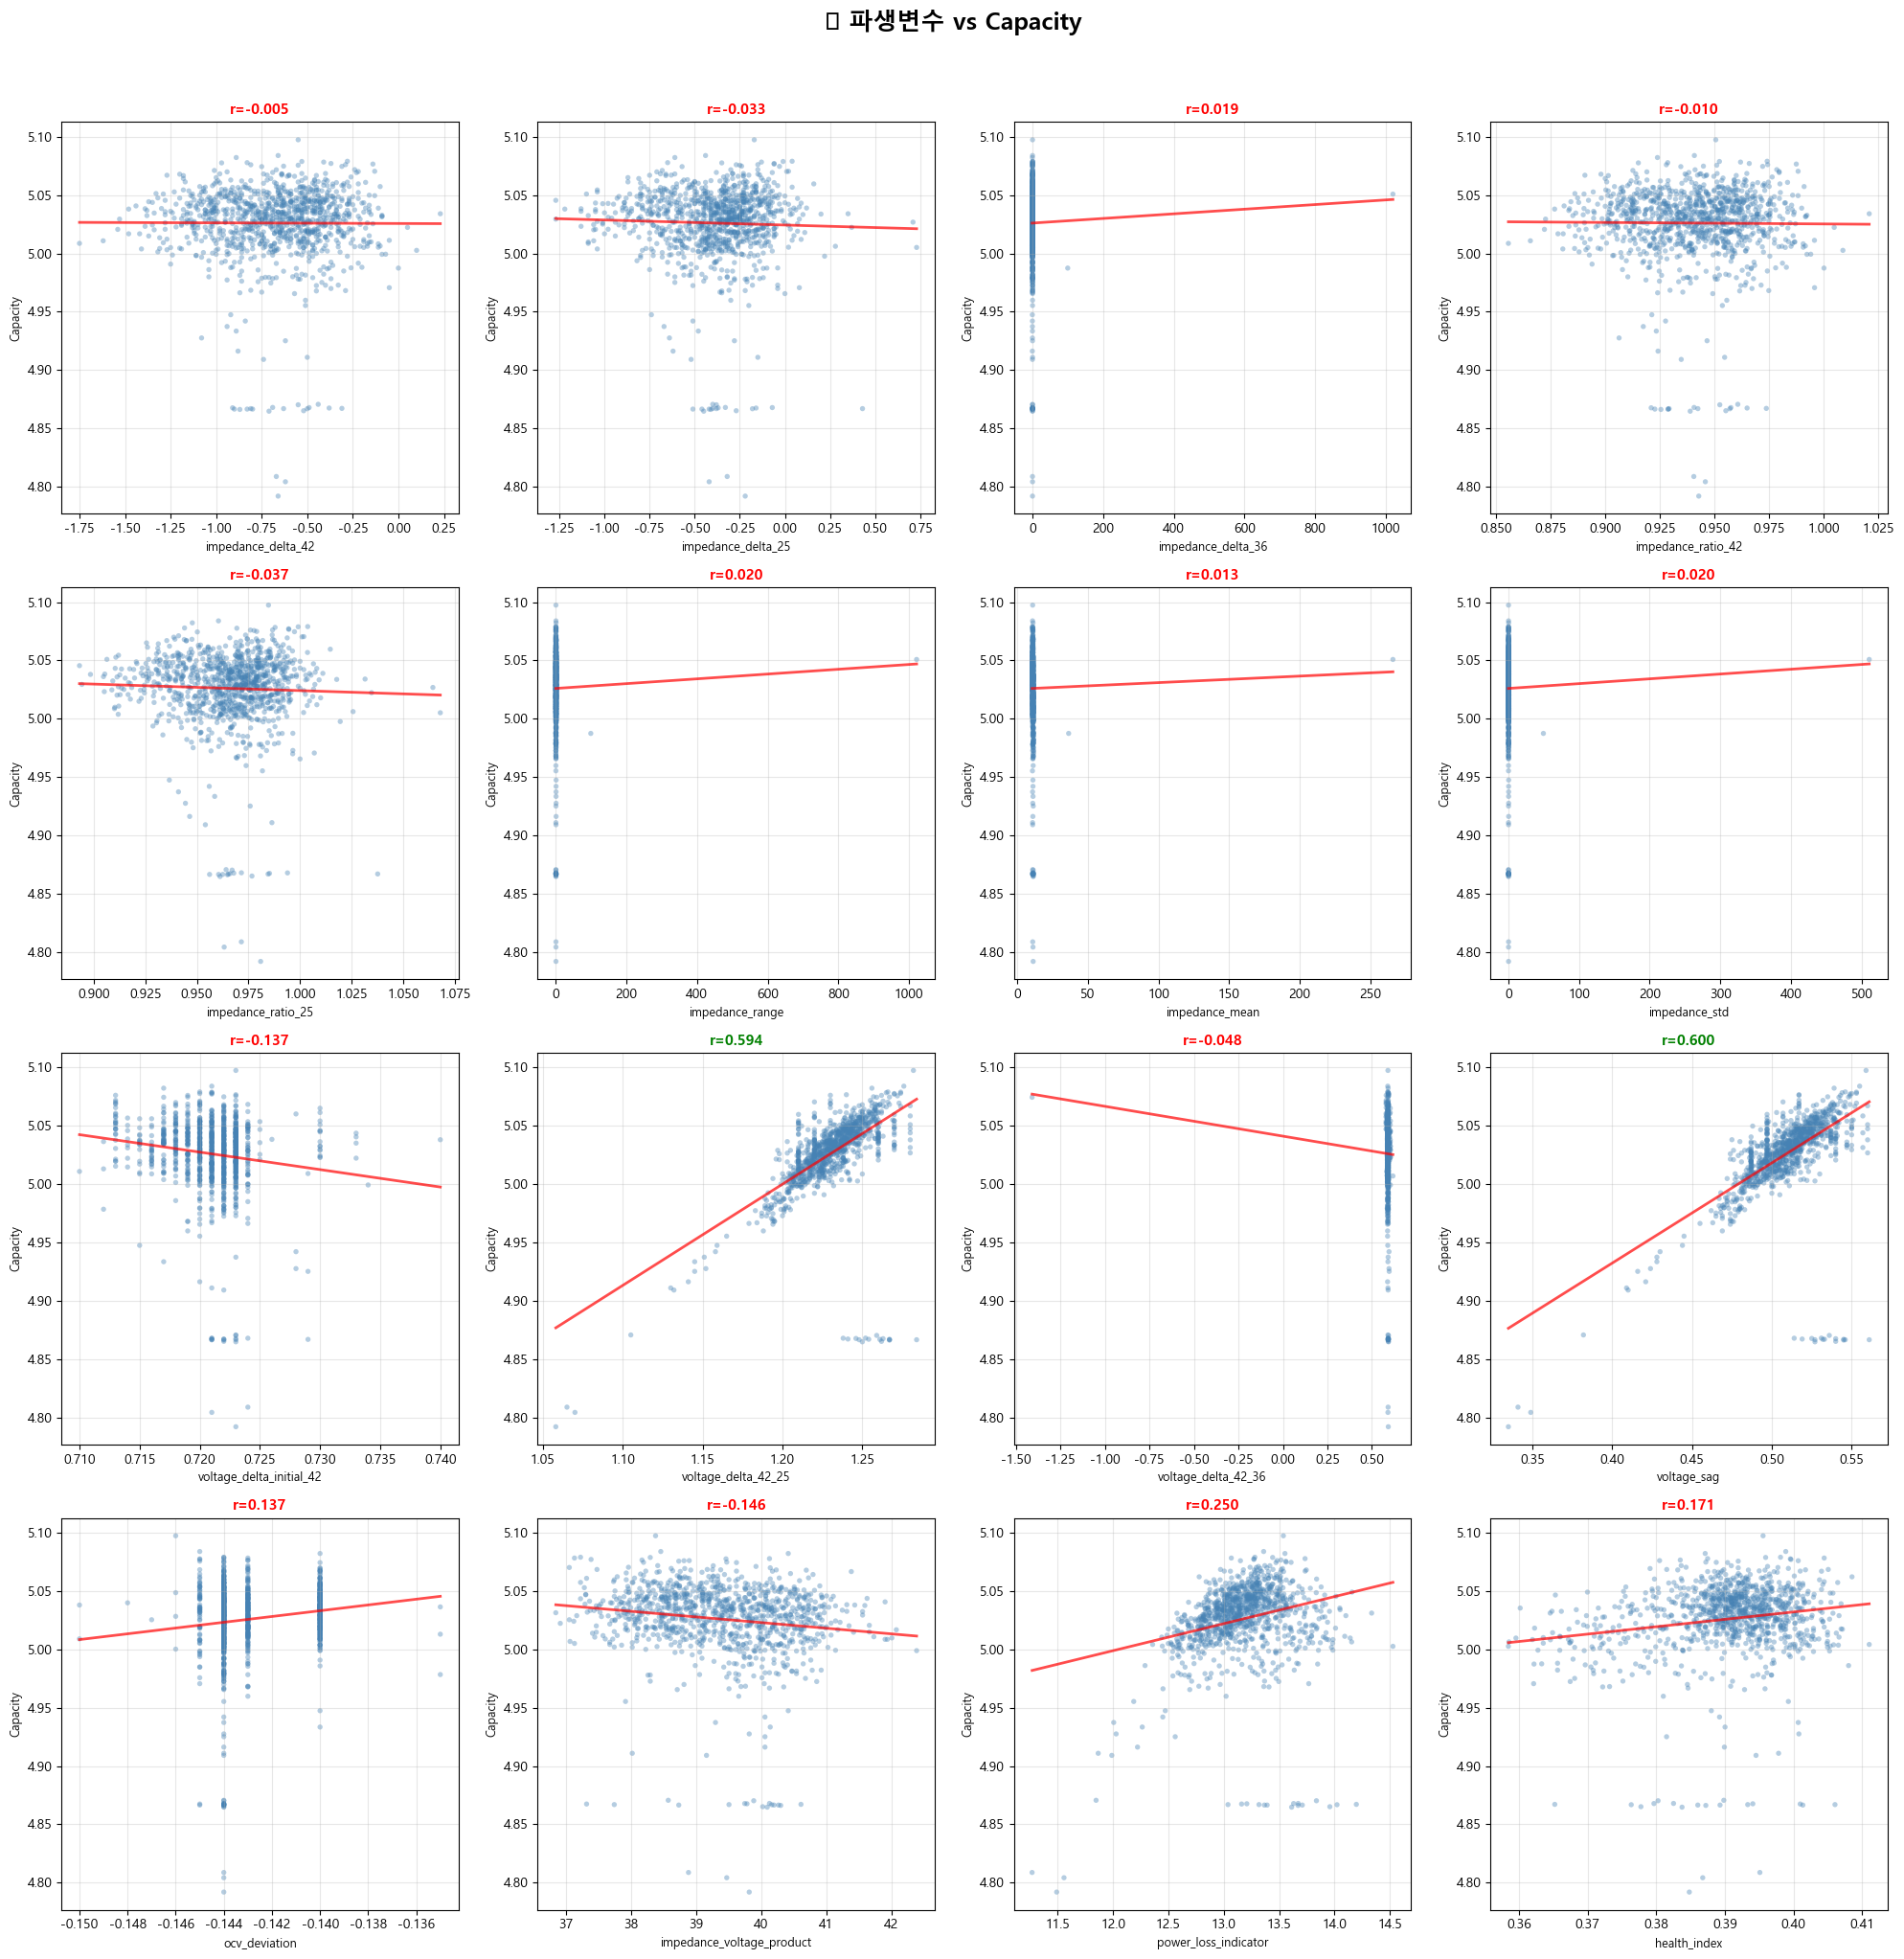

In [18]:
# 파생변수 vs Capacity 산점도
from scipy.stats import pearsonr

n_derived = len(ALL_DERIVED)
n_cols_plot = 4
n_rows_plot = (n_derived + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, 5 * n_rows_plot))
axes = axes.flatten()

for i, feat in enumerate(ALL_DERIVED):
    ax = axes[i]
    x = df[feat].dropna()
    y = df.loc[x.index, TARGET]
    r_val, p_val = pearsonr(x, y)
    ax.scatter(x, y, alpha=0.4, s=15, c='steelblue', edgecolors='none')
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_sorted = np.sort(x)
    ax.plot(x_sorted, p(x_sorted), 'r-', linewidth=2, alpha=0.7)
    color = 'green' if abs(r_val) > 0.5 else ('orange' if abs(r_val) > 0.3 else 'red')
    ax.set_title(f'r={r_val:.3f}', fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Capacity', fontsize=9)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📊 파생변수 vs Capacity', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# Phase 3: 데이터 전처리 및 피처 선택

1. 극단 이상치 제거
2. 다중공선성(VIF) 분석
3. 중복 피처 제거
4. 시나리오별 피처셋 확정

### 3-1. 극단 이상치 처리

In [19]:
# 극단 이상치 확인 (|impedance_delta_36| > 100 mΩ)
extreme_mask = df['impedance_delta_36'].abs() > 100
n_extreme = extreme_mask.sum()

print('🚨 극단 이상치 분석')
print(f'  |impedance_delta_36| > 100mΩ인 셀: {n_extreme}개')

if n_extreme > 0:
    extreme_cells = df[extreme_mask]
    for _, row in extreme_cells.iterrows():
        print(f'  셀 ID: {row["cell_id"]}')
        print(f'    v36_impedance = {row["v36_impedance"]} mΩ (정상 범위: 10~12 mΩ)')
        print(f'    → 명백한 측정 오류')

# 이상치 제거
df_clean = df[~extreme_mask].copy()
print(f'\n✅ 극단 이상치 제거: {len(df)}개 → {len(df_clean)}개 (제거: {n_extreme}개)')

🚨 극단 이상치 분석
  |impedance_delta_36| > 100mΩ인 셀: 1개
  셀 ID: BS-LSBAT-S240629-0126
    v36_impedance = 1032.0 mΩ (정상 범위: 10~12 mΩ)
    → 명백한 측정 오류

✅ 극단 이상치 제거: 1040개 → 1039개 (제거: 1개)


### 3-2. VIF (다중공선성) 분석

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

all_features_for_vif = FEATURES + ALL_DERIVED
X_vif = df_clean[all_features_for_vif].replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_vif), columns=X_vif.columns)

vif_data = []
for i, col in enumerate(X_scaled.columns):
    vif = variance_inflation_factor(X_scaled.values, i)
    vif_data.append({'피처': col, 'VIF': round(vif, 1)})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print('📊 전체 피처 VIF (Variance Inflation Factor)')
print('=' * 60)
for _, row in vif_df.iterrows():
    flag = '🔴' if row['VIF'] > 1000 else ('⚠️' if row['VIF'] > 10 else '✅')
    print(f'  {flag} {row["피처"]:35s}: VIF = {row["VIF"]:>15,.1f}')

print(f'\n⚠️ VIF > 10: {(vif_df["VIF"] > 10).sum()}개')

📊 전체 피처 VIF (Variance Inflation Factor)
  🔴 impedance_delta_25                 : VIF = 19,316,525,493.0
  🔴 impedance_delta_36                 : VIF = 5,779,402,794.2
  🔴 voltage_delta_42_36                : VIF = 4,395,406,691.7
  🔴 initial_impedance                  : VIF = 1,576,814,987.3
  🔴 voltage_delta_42_25                : VIF = 1,414,215,488.1
  🔴 impedance_mean                     : VIF = 1,401,770,212.0
  🔴 v36_voltage                        : VIF = 1,187,391,029.2
  🔴 v42_voltage                        : VIF = 1,156,297,374.9
  🔴 v42_impedance                      : VIF =   976,122,985.8
  🔴 v25_voltage                        : VIF =   912,421,734.2
  🔴 impedance_delta_42                 : VIF =   514,469,352.0
  🔴 v36_impedance                      : VIF =   442,590,442.4
  🔴 voltage_sag                        : VIF =   371,506,546.6
  🔴 v25_impedance                      : VIF =   193,877,361.7
  🔴 ocv_deviation                      : VIF =    70,249,474.3
  🔴 voltage_de

### 3-3. 중복 피처 제거

In [21]:
remove_features = []

# 1) impedance delta vs ratio 쌍: delta 제거, ratio 유지
remove_features.extend(['impedance_delta_42', 'impedance_delta_25'])
print('❌ 제거: impedance_delta_42/25 → ratio 유지 (동일 정보, ratio가 해석 용이)')

# 2) impedance_delta_36 계열: 이상치 왜곡, mean만 유지
remove_features.extend(['impedance_delta_36', 'impedance_range', 'impedance_std'])
print('❌ 제거: impedance_delta_36, range, std → impedance_mean 유지')

# 3) voltage_delta_42_25 vs voltage_sag: r=0.991 거의 동일
remove_features.append('voltage_delta_42_25')
print('❌ 제거: voltage_delta_42_25 → voltage_sag 유지 (r=0.600 미세 우위)')

# 4) voltage_delta_42_36: 약한 상관 + 이상치
remove_features.append('voltage_delta_42_36')
print('❌ 제거: voltage_delta_42_36 (약한 상관, 이상치)')

remaining_derived = [f for f in ALL_DERIVED if f not in remove_features]

print(f'\n📊 피처 정리 결과:')
print(f'   제거: {len(remove_features)}개')
print(f'   유지 파생변수: {len(remaining_derived)}개 → {remaining_derived}')
print(f'   최종 피처: 원본 {len(FEATURES)}개 + 파생 {len(remaining_derived)}개 = {len(FEATURES) + len(remaining_derived)}개')

❌ 제거: impedance_delta_42/25 → ratio 유지 (동일 정보, ratio가 해석 용이)
❌ 제거: impedance_delta_36, range, std → impedance_mean 유지
❌ 제거: voltage_delta_42_25 → voltage_sag 유지 (r=0.600 미세 우위)
❌ 제거: voltage_delta_42_36 (약한 상관, 이상치)

📊 피처 정리 결과:
   제거: 7개
   유지 파생변수: 9개 → ['impedance_ratio_42', 'impedance_ratio_25', 'impedance_mean', 'voltage_delta_initial_42', 'voltage_sag', 'ocv_deviation', 'impedance_voltage_product', 'power_loss_indicator', 'health_index']
   최종 피처: 원본 8개 + 파생 9개 = 17개


### 3-4. 시나리오별 피처셋 확정

측정 가능 범위에 따라 4가지 시나리오를 정의합니다.

In [22]:
remaining_all = FEATURES + remaining_derived

# 시나리오 정의
scenario1_features = ['initial_voltage', 'initial_impedance', 'ocv_deviation']

scenario2_features = ['initial_voltage', 'initial_impedance',
                      'v42_voltage', 'v42_impedance',
                      'impedance_ratio_42', 'voltage_delta_initial_42',
                      'impedance_voltage_product', 'health_index', 'ocv_deviation']

scenario3_features = scenario2_features + [
    'v36_voltage', 'v36_impedance', 'impedance_mean']

scenario4_features = remaining_all

scenarios = {
    'S1_INITIAL': scenario1_features,
    'S2_INITIAL_42V': scenario2_features,
    'S3_INITIAL_42V_36V': scenario3_features,
    'S4_ALL': scenario4_features,
}

print('📋 시나리오별 피처 구성')
print('=' * 70)
for name, feats in scenarios.items():
    corrs = [(f, df_clean[f].corr(df_clean[TARGET])) for f in feats]
    corrs.sort(key=lambda x: abs(x[1]), reverse=True)
    max_r = max(abs(r) for _, r in corrs)
    print(f'\n{name} ({len(feats)}개 피처, 최대|r|={max_r:.3f}):')
    for f, r in corrs:
        strength = '🟢' if abs(r) > 0.5 else ('🟡' if abs(r) > 0.2 else '🔴')
        print(f'  {strength} {f:35s}: r={r:+.4f}')

print('\n' + '=' * 70)
print('✅ Phase 3 완료')

📋 시나리오별 피처 구성

S1_INITIAL (3개 피처, 최대|r|=0.149):
  🔴 initial_impedance                  : r=-0.1495
  🔴 initial_voltage                    : r=+0.1375
  🔴 ocv_deviation                      : r=+0.1375

S2_INITIAL_42V (9개 피처, 최대|r|=0.177):
  🔴 v42_impedance                      : r=-0.1770
  🔴 health_index                       : r=+0.1705
  🔴 initial_impedance                  : r=-0.1495
  🔴 impedance_voltage_product          : r=-0.1452
  🔴 voltage_delta_initial_42           : r=-0.1383
  🔴 initial_voltage                    : r=+0.1375
  🔴 ocv_deviation                      : r=+0.1375
  🔴 v42_voltage                        : r=-0.0647
  🔴 impedance_ratio_42                 : r=-0.0097

S3_INITIAL_42V_36V (12개 피처, 최대|r|=0.177):
  🔴 v42_impedance                      : r=-0.1770
  🔴 health_index                       : r=+0.1705
  🔴 initial_impedance                  : r=-0.1495
  🔴 impedance_voltage_product          : r=-0.1452
  🔴 voltage_delta_initial_42           : r=-0.1383
  🔴 

---
# Phase 4: 학습 데이터 구성

- Train/Test 분할 (80:20, random_state=42)
- 시나리오별 데이터셋 구성
- 스케일링 준비

### 4-1. Train/Test 분할

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from scipy.stats import ks_2samp

X = df_clean[remaining_all]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('📊 Train/Test 분할 결과')
print('=' * 50)
print(f'  전체: {len(df_clean)}개')
print(f'  Train: {len(X_train)}개 ({len(X_train)/len(df_clean)*100:.1f}%)')
print(f'  Test:  {len(X_test)}개 ({len(X_test)/len(df_clean)*100:.1f}%)')
print(f'\n  Train Capacity: mean={y_train.mean():.4f}, std={y_train.std():.4f}')
print(f'  Test  Capacity: mean={y_test.mean():.4f}, std={y_test.std():.4f}')

# 분포 동질성 KS 검정
ks_stat, ks_p = ks_2samp(y_train, y_test)
print(f'\n  KS 검정: statistic={ks_stat:.4f}, p={ks_p:.4f}')
print(f'  → Train/Test 분포 동질성: {"✅ 확인" if ks_p > 0.05 else "⚠️ 차이 있음"}')

📊 Train/Test 분할 결과
  전체: 1039개
  Train: 831개 (80.0%)
  Test:  208개 (20.0%)

  Train Capacity: mean=5.0267, std=0.0320
  Test  Capacity: mean=5.0231, std=0.0366

  KS 검정: statistic=0.0653, p=0.4561
  → Train/Test 분포 동질성: ✅ 확인


### 4-2. 시나리오별 데이터셋 구성

In [24]:
scenario_datasets = {}
print('📋 시나리오별 데이터셋 구성')
print('=' * 70)

for name, feats in scenarios.items():
    X_tr = X_train[feats]
    X_te = X_test[feats]
    scenario_datasets[name] = {
        'X_train': X_tr, 'X_test': X_te,
        'y_train': y_train, 'y_test': y_test,
        'features': feats
    }
    na_count = X_tr.isna().sum().sum() + X_te.isna().sum().sum()
    inf_count = np.isinf(X_tr.select_dtypes(include=[np.number])).sum().sum()
    print(f'  {name} ({len(feats)}개 피처): Train {X_tr.shape}, Test {X_te.shape} | 결측: {na_count}, 무한: {inf_count} → {"✅" if na_count+inf_count == 0 else "⚠️"}')

print(f'\n✅ 4개 시나리오 데이터셋 준비 완료')

📋 시나리오별 데이터셋 구성
  S1_INITIAL (3개 피처): Train (831, 3), Test (208, 3) | 결측: 0, 무한: 0 → ✅
  S2_INITIAL_42V (9개 피처): Train (831, 9), Test (208, 9) | 결측: 0, 무한: 0 → ✅
  S3_INITIAL_42V_36V (12개 피처): Train (831, 12), Test (208, 12) | 결측: 0, 무한: 0 → ✅
  S4_ALL (17개 피처): Train (831, 17), Test (208, 17) | 결측: 0, 무한: 0 → ✅

✅ 4개 시나리오 데이터셋 준비 완료


In [25]:
for name, feats in scenarios.items():
    print(name)

S1_INITIAL
S2_INITIAL_42V
S3_INITIAL_42V_36V
S4_ALL


### 4-3. 스케일링 준비

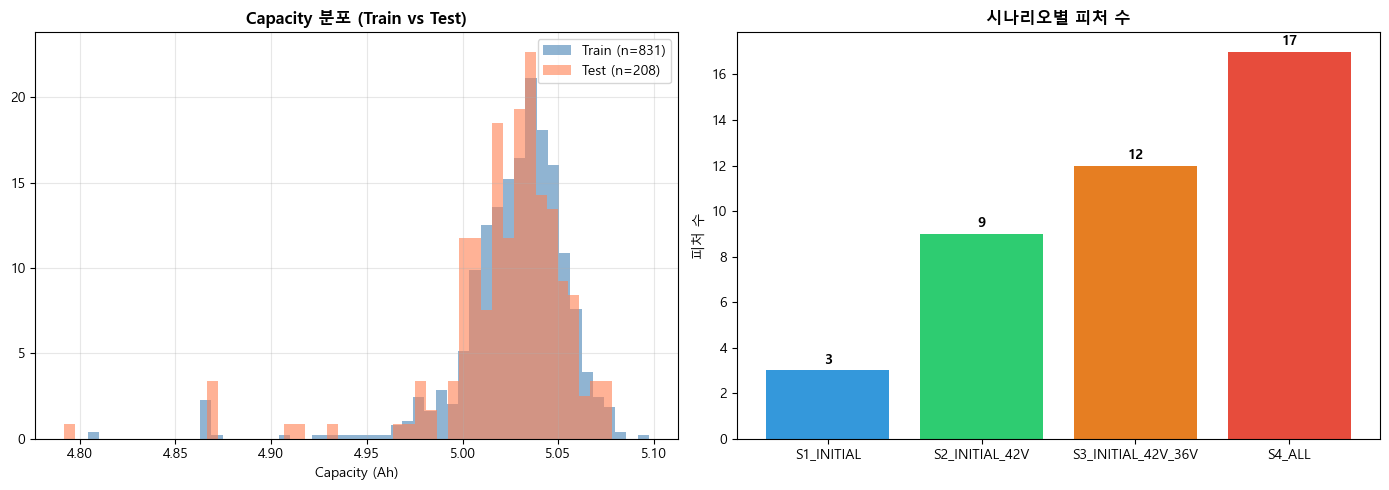

💡 트리 기반 모델: 스케일링 없이 원본 투입
💡 선형 모델/SVR: RobustScaler 적용

✅ Phase 4 완료 → Phase 5 (모델 학습)로 진행


In [26]:
# 헬퍼 함수 정의
def get_scenario_data(scenario_features, X_train, X_test):
    return X_train[scenario_features], X_test[scenario_features]

# Train/Test 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=50, alpha=0.6, label=f'Train (n={len(y_train)})',
             color='steelblue', density=True)
axes[0].hist(y_test, bins=50, alpha=0.6, label=f'Test (n={len(y_test)})',
             color='coral', density=True)
axes[0].set_title('Capacity 분포 (Train vs Test)', fontweight='bold')
axes[0].set_xlabel('Capacity (Ah)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

s_names = list(scenarios.keys())
s_counts = [len(v) for v in scenarios.values()]
bars = axes[1].bar(s_names, s_counts, color=['#3498db','#2ecc71','#e67e22','#e74c3c'])
axes[1].set_title('시나리오별 피처 수', fontweight='bold')
axes[1].set_ylabel('피처 수')
for bar, cnt in zip(bars, s_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.3,
                 str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 트리 기반 모델: 스케일링 없이 원본 투입')
print('💡 선형 모델/SVR: RobustScaler 적용')
print('\n✅ Phase 4 완료 → Phase 5 (모델 학습)로 진행')

---
# Phase 5: 기본 모델 학습 및 평가

4가지 시나리오에 5개 모델을 학습하고 성능을 비교합니다.

| 모델 | 유형 |
|------|------|
| Linear Regression | Baseline |
| SVR | 비선형 커널 |
| Random Forest | 앙상블 |
| XGBoost | Boosting |
| LightGBM | Boosting |

In [27]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

models = {
    'LinearReg': LinearRegression(),
    'SVR': SVR(C=1.0, epsilon=0.01),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

scale_needed = ['LinearReg', 'SVR']
results_list = []
trained_models = {}

print('🚀 Phase 5: 모델 학습 시작')
print('=' * 80)

for s_name, feats in scenarios.items():
    print(f'\n[{s_name}] (Features: {len(feats)})')
    print('-' * 60)
    
    X_tr_curr, X_te_curr = get_scenario_data(feats, X_train, X_test)
    
    scaler = RobustScaler()
    X_tr_scaled = pd.DataFrame(scaler.fit_transform(X_tr_curr), columns=feats, index=X_tr_curr.index)
    X_te_scaled = pd.DataFrame(scaler.transform(X_te_curr), columns=feats, index=X_te_curr.index)
    
    for m_name, model in models.items():
        if m_name in scale_needed:
            X_train_final, X_test_final = X_tr_scaled, X_te_scaled
        else:
            X_train_final, X_test_final = X_tr_curr, X_te_curr
        
        start = time.time()
        model.fit(X_train_final, y_train)
        elapsed = time.time() - start
        
        trained_models[f'{s_name}_{m_name}'] = model
        
        y_pred = model.predict(X_test_final)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        
        print(f'{m_name:12s} | RMSE={rmse:.4f}, R2={r2:.4f}, MAPE={mape:.4f} ({elapsed:.2f}s)')
        
        results_list.append({
            'Scenario': s_name, 'Model': m_name,
            'RMSE': rmse, 'R2': r2, 'MAPE': mape
        })

print('=' * 80)
print('✅ Phase 5 학습 완료')
results_df = pd.DataFrame(results_list)

🚀 Phase 5: 모델 학습 시작

[S1_INITIAL] (Features: 3)
------------------------------------------------------------
LinearReg    | RMSE=0.0355, R2=0.0548, MAPE=0.0042 (0.00s)
SVR          | RMSE=0.0357, R2=0.0490, MAPE=0.0041 (0.01s)
RandomForest | RMSE=0.0393, R2=-0.1572, MAPE=0.0048 (0.09s)
XGBoost      | RMSE=0.0377, R2=-0.0618, MAPE=0.0046 (0.16s)
LightGBM     | RMSE=0.0365, R2=0.0033, MAPE=0.0045 (0.03s)

[S2_INITIAL_42V] (Features: 9)
------------------------------------------------------------
LinearReg    | RMSE=0.0356, R2=0.0499, MAPE=0.0042 (0.00s)
SVR          | RMSE=0.0348, R2=0.0948, MAPE=0.0040 (0.03s)
RandomForest | RMSE=0.0372, R2=-0.0359, MAPE=0.0045 (0.10s)
XGBoost      | RMSE=0.0387, R2=-0.1179, MAPE=0.0048 (0.04s)
LightGBM     | RMSE=0.0380, R2=-0.0801, MAPE=0.0048 (0.03s)

[S3_INITIAL_42V_36V] (Features: 12)
------------------------------------------------------------
LinearReg    | RMSE=0.0352, R2=0.0730, MAPE=0.0042 (0.00s)
SVR          | RMSE=0.0357, R2=0.0469, MAPE=0.

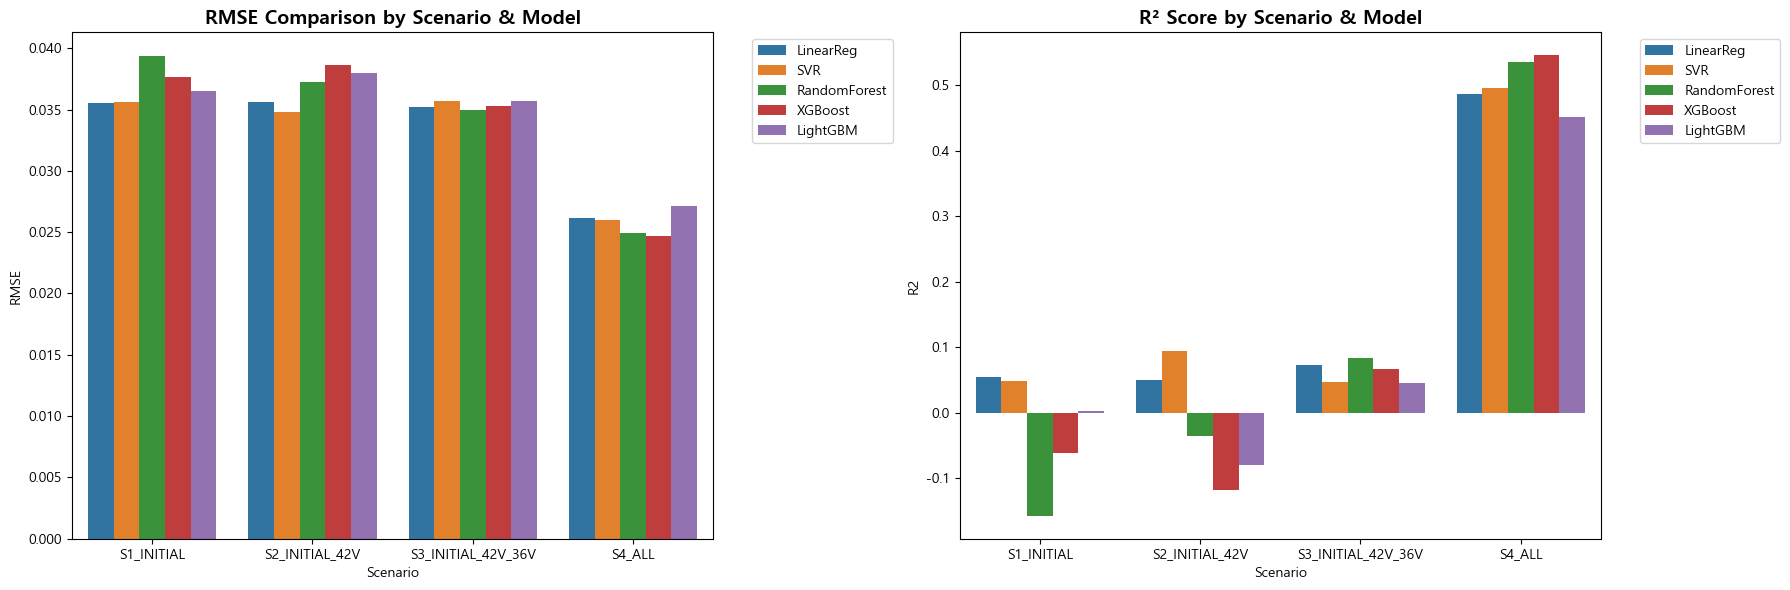


🏆 시나리오별 최고 성능 모델:
  S1_INITIAL: LinearReg (RMSE=0.0355, R²=0.0548)
  S2_INITIAL_42V: SVR (RMSE=0.0348, R²=0.0948)
  S3_INITIAL_42V_36V: RandomForest (RMSE=0.0350, R²=0.0838)
  S4_ALL: XGBoost (RMSE=0.0246, R²=0.5454)


In [28]:
# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=results_df, x='Scenario', y='RMSE', hue='Model', ax=axes[0])
axes[0].set_title('RMSE Comparison by Scenario & Model', fontsize=14, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sns.barplot(data=results_df, x='Scenario', y='R2', hue='Model', ax=axes[1])
axes[1].set_title('R² Score by Scenario & Model', fontsize=14, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 시나리오별 최고 성능
print('\n🏆 시나리오별 최고 성능 모델:')
for s in scenarios.keys():
    subset = results_df[results_df['Scenario'] == s]
    best = subset.loc[subset['RMSE'].idxmin()]
    print(f'  {s}: {best["Model"]} (RMSE={best["RMSE"]:.4f}, R²={best["R2"]:.4f})')

---
# Phase 6: Multi-AutoML 벤치마킹

4개 시나리오에 대해 전문 AutoML 프레임워크를 적용하여 성능을 극대화합니다.

| 트랙 | 프레임워크 | 특징 |
|------|-----------|------|
| **1** | CatBoost | 배터리 도메인 최적 트리 앙상블 |
| **2** | SVR (RBF) | 비선형 커널 기반 회귀 |
| **3** | FLAML | Microsoft Fast AutoML (30초 예산) |
| **4** | AutoGluon | AWS 앙상블 Tabular (60초 예산) |

In [29]:
from catboost import CatBoostRegressor
from flaml import AutoML
from autogluon.tabular import TabularPredictor
from sklearn.metrics import mean_absolute_error

print('🚀 Phase 6: 시나리오(S1~S4)별 다중 벤치마킹')
print('비교 트랙: 1) CatBoost, 2) SVR, 3) FLAML, 4) AutoGluon')
print('=' * 70)

benchmark_results = []

for name, feats in scenarios.items():
    print(f'\n▶️ 시나리오: {name}')
    
    X_train_s = scenario_datasets[name]['X_train']
    X_test_s = scenario_datasets[name]['X_test']
    y_train_s = scenario_datasets[name]['y_train']
    y_test_s = scenario_datasets[name]['y_test']
    
    # === Track 1: CatBoost ===
    print('  - Track 1. CatBoost')
    cb = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
    cb.fit(X_train_s, y_train_s)
    pred_cb = cb.predict(X_test_s)
    benchmark_results.append({
        'Scenario': name, 'Model_Track': '1_CatBoost',
        'R2': r2_score(y_test_s, pred_cb),
        'RMSE': np.sqrt(mean_squared_error(y_test_s, pred_cb)),
        'MAE': mean_absolute_error(y_test_s, pred_cb)
    })
    
    # === Track 2: SVR ===
    print('  - Track 2. SVR (RBF)')
    scaler_svr = RobustScaler()
    X_tr_sc = scaler_svr.fit_transform(X_train_s)
    X_te_sc = scaler_svr.transform(X_test_s)
    svr = SVR(C=1.0, epsilon=0.1, kernel='rbf')
    svr.fit(X_tr_sc, y_train_s)
    pred_svr = svr.predict(X_te_sc)
    benchmark_results.append({
        'Scenario': name, 'Model_Track': '2_SVR',
        'R2': r2_score(y_test_s, pred_svr),
        'RMSE': np.sqrt(mean_squared_error(y_test_s, pred_svr)),
        'MAE': mean_absolute_error(y_test_s, pred_svr)
    })
    
    # === Track 3: FLAML ===
    print('  - Track 3. FLAML (30s budget)')
    flaml_automl = AutoML()
    flaml_settings = {
        'time_budget': 30,
        'metric': 'r2',
        'task': 'regression',
        'eval_method': 'cv',
        'log_file_name': f'flaml_{name}.log',
        'verbose': 0
    }
    flaml_automl.fit(X_train=X_train_s, y_train=y_train_s, **flaml_settings)
    pred_flaml = flaml_automl.predict(X_test_s)
    benchmark_results.append({
        'Scenario': name, 'Model_Track': f'3_FLAML ({flaml_automl.best_estimator})',
        'R2': r2_score(y_test_s, pred_flaml),
        'RMSE': np.sqrt(mean_squared_error(y_test_s, pred_flaml)),
        'MAE': mean_absolute_error(y_test_s, pred_flaml)
    })
    
    # === Track 4: AutoGluon ===
    print('  - Track 4. AutoGluon (60s limit)')
    train_data_ag = pd.concat([X_train_s, y_train_s], axis=1)
    test_data_ag = pd.concat([X_test_s, y_test_s], axis=1)
    predictor_ag = TabularPredictor(
        label=TARGET, path=f'AutogluonModels_{name}', eval_metric='r2'
    ).fit(train_data_ag, presets='medium_quality', time_limit=60, verbosity=0)
    pred_ag = predictor_ag.predict(test_data_ag.drop(columns=[TARGET]))
    benchmark_results.append({
        'Scenario': name, 'Model_Track': '4_AutoGluon (Ensemble)',
        'R2': r2_score(y_test_s, pred_ag),
        'RMSE': np.sqrt(mean_squared_error(y_test_s, pred_ag)),
        'MAE': mean_absolute_error(y_test_s, pred_ag)
    })
    print('  ✓ 완료')

print('\n' + '=' * 70)
print('✅ Phase 6 벤치마킹 완료')
bench_df = pd.DataFrame(benchmark_results)
display(bench_df.sort_values(by=['Scenario', 'R2'], ascending=[True, False]))

🚀 Phase 6: 시나리오(S1~S4)별 다중 벤치마킹
비교 트랙: 1) CatBoost, 2) SVR, 3) FLAML, 4) AutoGluon

▶️ 시나리오: S1_INITIAL
  - Track 1. CatBoost
  - Track 2. SVR (RBF)
  - Track 3. FLAML (30s budget)


  - Track 4. AutoGluon (60s limit)


		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 


  ✓ 완료

▶️ 시나리오: S2_INITIAL_42V
  - Track 1. CatBoost


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


...

  - Track 2. SVR (RBF)
  - Track 3. FLAML (30s budget)


  - Track 4. AutoGluon (60s limit)


		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.5.0`. 


  ✓ 완료

✅ Phase 6 벤치마킹 완료


,Scenario,Model_Track,R2,RMSE,MAE
3,S1_INITIAL,4_AutoGluon (Ensemble),0.088682,0.034901,0.020830
2,S1_INITIAL,3_FLAML (rf),0.082320,0.035022,0.021134
0,S1_INITIAL,1_CatBoost,0.024132,0.036116,0.022014
1,S1_INITIAL,2_SVR,-1.662530,0.059655,0.054987
7,S2_INITIAL_42V,4_AutoGluon (Ensemble),0.144496,0.033815,0.020141
4,S2_INITIAL_42V,1_CatBoost,0.033821,0.035936,0.022074
6,S2_INITIAL_42V,3_FLAML (catboost),0.023402,0.036129,0.022014
5,S2_INITIAL_42V,2_SVR,-1.898276,0.062240,0.057945
10,S3_INITIAL_42V_36V,3_FLAML (extra_tree),0.107889,0.034531,0.020414
11,S3_INITIAL_42V_36V,4_AutoGluon (Ensemble),0.096598,0.034749,0.020915


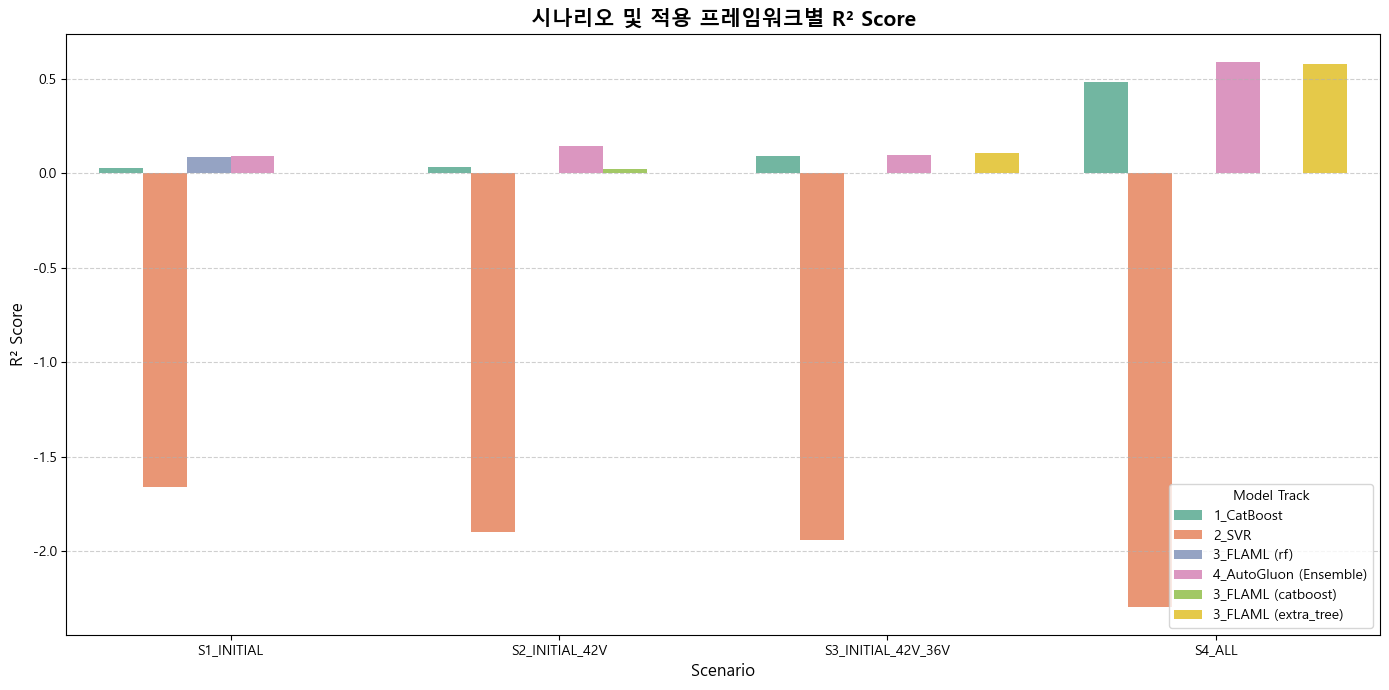

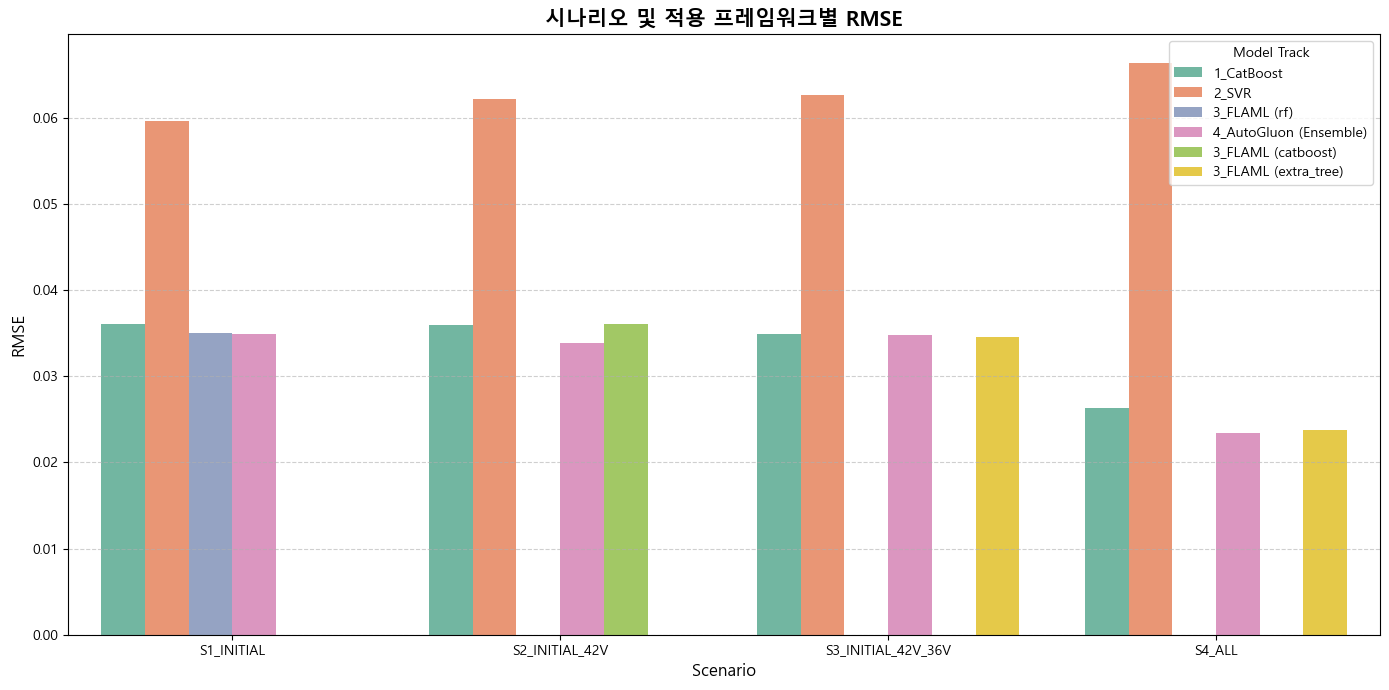

In [30]:
# Phase 6 성능 시각화
plt.figure(figsize=(14, 7))
sns.barplot(data=bench_df, x='Scenario', y='R2', hue='Model_Track', palette='Set2')
plt.title('시나리오 및 적용 프레임워크별 R² Score', fontsize=15, fontweight='bold')
plt.ylabel('R² Score', fontsize=12)
plt.xlabel('Scenario', fontsize=12)
plt.legend(title='Model Track', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# RMSE 비교
plt.figure(figsize=(14, 7))
sns.barplot(data=bench_df, x='Scenario', y='RMSE', hue='Model_Track', palette='Set2')
plt.title('시나리오 및 적용 프레임워크별 RMSE', fontsize=15, fontweight='bold')
plt.ylabel('RMSE', fontsize=12)
plt.xlabel('Scenario', fontsize=12)
plt.legend(title='Model Track', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
# Phase 7: 최고 성능 모델 해석 (Feature Importance & SHAP)

Phase 6 벤치마킹 결과에서 **R² 최고 모델**을 자동 식별하고, 변수 중요도 및 SHAP 분석을 수행합니다.

In [31]:
# 7-1. 벤치마크 1위 모델 식별
best_row = bench_df.sort_values(by='R2', ascending=False).iloc[0]
best_scenario_name = best_row['Scenario']
best_track_name = best_row['Model_Track']
best_r2 = best_row['R2']

print('=' * 70)
print(f'🏆 벤치마크 1위 최고 성능 모델')
print(f'   - 시나리오: {best_scenario_name}')
print(f'   - 프레임워크: {best_track_name}')
print(f'   - Test R² Score: {best_r2:.4f}')
print('=' * 70)

# 데이터 준비
X_train_best = scenario_datasets[best_scenario_name]['X_train']
X_test_best = scenario_datasets[best_scenario_name]['X_test']
y_train_best = scenario_datasets[best_scenario_name]['y_train']
y_test_best = scenario_datasets[best_scenario_name]['y_test']
best_feature_names = scenario_datasets[best_scenario_name]['features']

🏆 벤치마크 1위 최고 성능 모델
   - 시나리오: S4_ALL
   - 프레임워크: 4_AutoGluon (Ensemble)
   - Test R² Score: 0.5893


▶️ AutoGluon 변수 중요도 추출 (Permutation 기반)


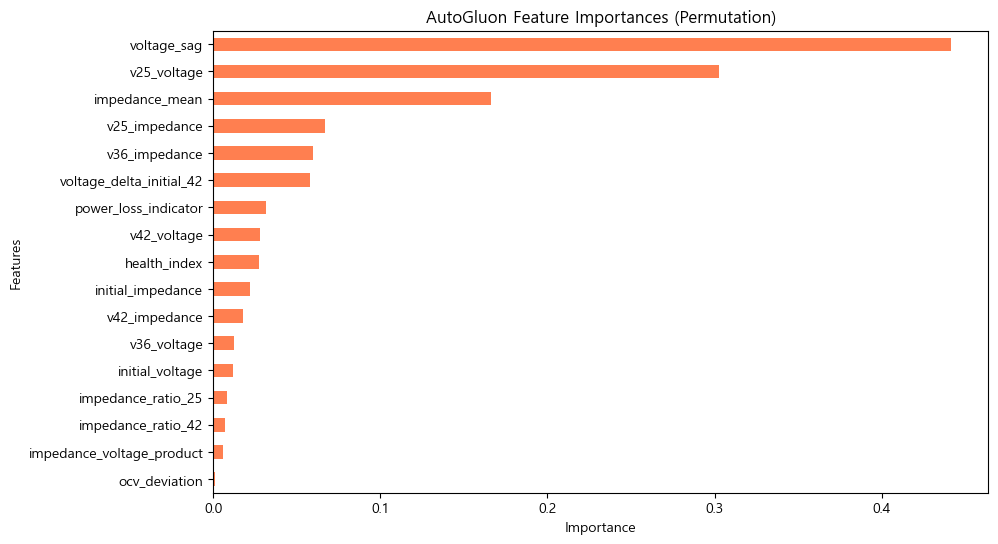

In [32]:
# 7-2. 모델 재학습 및 SHAP 분석
import shap

plt.figure(figsize=(10, 6))

if 'CatBoost' in best_track_name:
    print('▶️ CatBoost 모델 SHAP 분석 (TreeExplainer)')
    best_model_obj = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
    best_model_obj.fit(X_train_best, y_train_best)
    explainer = shap.TreeExplainer(best_model_obj)
    shap_values = explainer.shap_values(X_test_best)
    shap.summary_plot(shap_values, X_test_best, feature_names=best_feature_names)

elif 'SVR' in best_track_name:
    print('▶️ SVR 모델 SHAP 분석 (KernelExplainer)')
    scaler_svr = RobustScaler()
    X_tr_sc = scaler_svr.fit_transform(X_train_best)
    X_te_sc = scaler_svr.transform(X_test_best)
    best_model_obj = SVR(C=1.0, epsilon=0.1, kernel='rbf')
    best_model_obj.fit(X_tr_sc, y_train_best)
    X_train_summary = shap.kmeans(X_tr_sc, 20)
    explainer = shap.KernelExplainer(best_model_obj.predict, X_train_summary)
    shap_values = explainer.shap_values(X_te_sc[:100])
    shap.summary_plot(shap_values, pd.DataFrame(X_te_sc[:100], columns=best_feature_names), feature_names=best_feature_names)

elif 'FLAML' in best_track_name:
    print('▶️ FLAML 최고 모델 SHAP 분석 (TreeExplainer)')
    flaml_automl_best = AutoML()
    flaml_automl_best.fit(X_train=X_train_best, y_train=y_train_best, time_budget=30, metric='r2', task='regression', verbose=0)
    best_model_obj = flaml_automl_best.model.estimator
    try:
        explainer = shap.TreeExplainer(best_model_obj)
        shap_values = explainer.shap_values(X_test_best)
        shap.summary_plot(shap_values, X_test_best, feature_names=best_feature_names)
    except Exception:
        print('트리 모델 외 → Feature Importance만 출력')
        pd.Series(best_model_obj.feature_importances_, index=best_feature_names).sort_values().plot.barh(color='skyblue')
        plt.title('FLAML Feature Importances')
        plt.show()

elif 'AutoGluon' in best_track_name:
    print('▶️ AutoGluon 변수 중요도 추출 (Permutation 기반)')
    predictor_path = f'AutogluonModels_{best_scenario_name}'
    predictor_best = TabularPredictor.load(predictor_path)
    train_data_ag = pd.concat([X_train_best, y_train_best], axis=1)
    feature_importance_df = predictor_best.feature_importance(train_data_ag)
    feature_importance_df['importance'].sort_values().plot.barh(color='coral')
    plt.title('AutoGluon Feature Importances (Permutation)')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.show()
    best_model_obj = predictor_best

else:
    print('지원하지 않는 모델 트랙')

In [33]:
# 7-3. 전체 벤치마크 결과 종합 요약
print('\n📊 Phase 5 + Phase 6 전체 성능 종합')
print('=' * 70)

# Phase 5 결과
print('\n[Phase 5 - 기본 모델]')
p5_best = results_df.sort_values('RMSE').head(5)
for _, row in p5_best.iterrows():
    print(f'  {row["Scenario"]:20s} | {row["Model"]:12s} | RMSE={row["RMSE"]:.4f} | R²={row["R2"]:.4f}')

# Phase 6 결과
print('\n[Phase 6 - AutoML]')
p6_best = bench_df.sort_values('RMSE').head(5)
for _, row in p6_best.iterrows():
    print(f'  {row["Scenario"]:20s} | {row["Model_Track"]:30s} | RMSE={row["RMSE"]:.4f} | R²={row["R2"]:.4f}')

print(f'\n🏆 전체 최고 성능: {best_scenario_name} + {best_track_name} (R²={best_r2:.4f})')


📊 Phase 5 + Phase 6 전체 성능 종합

[Phase 5 - 기본 모델]
  S4_ALL               | XGBoost      | RMSE=0.0246 | R²=0.5454
  S4_ALL               | RandomForest | RMSE=0.0249 | R²=0.5350
  S4_ALL               | SVR          | RMSE=0.0260 | R²=0.4956
  S4_ALL               | LinearReg    | RMSE=0.0262 | R²=0.4871
  S4_ALL               | LightGBM     | RMSE=0.0271 | R²=0.4507

[Phase 6 - AutoML]
  S4_ALL               | 4_AutoGluon (Ensemble)         | RMSE=0.0234 | R²=0.5893
  S4_ALL               | 3_FLAML (extra_tree)           | RMSE=0.0238 | R²=0.5771
  S4_ALL               | 1_CatBoost                     | RMSE=0.0263 | R²=0.4812
  S2_INITIAL_42V       | 4_AutoGluon (Ensemble)         | RMSE=0.0338 | R²=0.1445
  S3_INITIAL_42V_36V   | 3_FLAML (extra_tree)           | RMSE=0.0345 | R²=0.1079

🏆 전체 최고 성능: S4_ALL + 4_AutoGluon (Ensemble) (R²=0.5893)


---
# Phase 8: 최종 모델 테스트 및 결론

Phase 7에서 식별된 최고 성능 모델로 최종 테스트를 수행하고 결과를 시각화합니다.

In [34]:
# 8-1. 최종 모델 테스트 성능 산출

# best_model_obj로 테스트 예측
if 'AutoGluon' in best_track_name:
    y_pred_final = best_model_obj.predict(X_test_best)
elif 'SVR' in best_track_name:
    scaler_final = RobustScaler()
    scaler_final.fit(X_train_best)
    X_test_sc = scaler_final.transform(X_test_best)
    y_pred_final = best_model_obj.predict(X_test_sc)
else:
    y_pred_final = best_model_obj.predict(X_test_best)

final_rmse = np.sqrt(mean_squared_error(y_test_best, y_pred_final))
final_r2 = r2_score(y_test_best, y_pred_final)
final_mape = mean_absolute_percentage_error(y_test_best, y_pred_final)
final_mae = mean_absolute_error(y_test_best, y_pred_final)

print('=' * 70)
print('📊 Phase 8: 최종 모델 테스트 결과')
print('=' * 70)
print(f'  모델: {best_track_name}')
print(f'  시나리오: {best_scenario_name}')
print(f'  피처 수: {len(best_feature_names)}')
print(f'\n  📏 성능 지표:')
print(f'     RMSE  = {final_rmse:.6f} Ah')
print(f'     R²    = {final_r2:.4f}')
print(f'     MAPE  = {final_mape:.4f} ({final_mape*100:.2f}%)')
print(f'     MAE   = {final_mae:.6f} Ah')
print('=' * 70)

📊 Phase 8: 최종 모델 테스트 결과
  모델: 4_AutoGluon (Ensemble)
  시나리오: S4_ALL
  피처 수: 17

  📏 성능 지표:
     RMSE  = 0.023428 Ah
     R²    = 0.5893
     MAPE  = 0.0024 (0.24%)
     MAE   = 0.011908 Ah


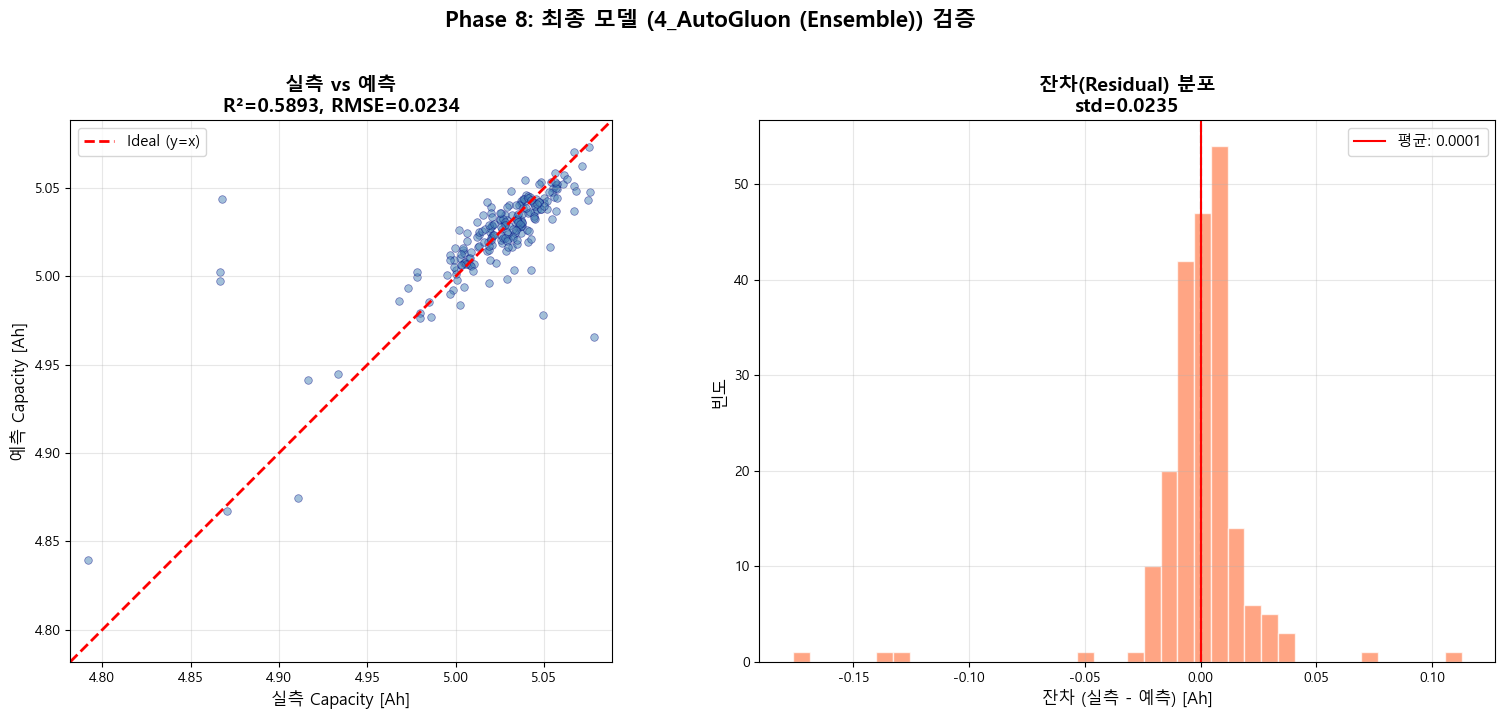

In [35]:
# 8-2. 실측 vs 예측 산점도
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (a) 실측 vs 예측 산점도
ax = axes[0]
ax.scatter(y_test_best, y_pred_final, alpha=0.5, s=30, c='steelblue', edgecolors='navy', linewidth=0.5)
lims = [min(y_test_best.min(), np.min(y_pred_final)) - 0.01,
        max(y_test_best.max(), np.max(y_pred_final)) + 0.01]
ax.plot(lims, lims, 'r--', linewidth=2, label='Ideal (y=x)')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('실측 Capacity [Ah]', fontsize=12)
ax.set_ylabel('예측 Capacity [Ah]', fontsize=12)
ax.set_title(f'실측 vs 예측\nR²={final_r2:.4f}, RMSE={final_rmse:.4f}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# (b) 잔차(Residual) 분포
ax2 = axes[1]
residuals = y_test_best.values - y_pred_final
ax2.hist(residuals, bins=40, alpha=0.7, color='coral', edgecolor='white')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax2.axvline(x=residuals.mean(), color='red', linestyle='-', linewidth=1.5, label=f'평균: {residuals.mean():.4f}')
ax2.set_xlabel('잔차 (실측 - 예측) [Ah]', fontsize=12)
ax2.set_ylabel('빈도', fontsize=12)
ax2.set_title(f'잔차(Residual) 분포\nstd={residuals.std():.4f}', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Phase 8: 최종 모델 ({best_track_name}) 검증', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

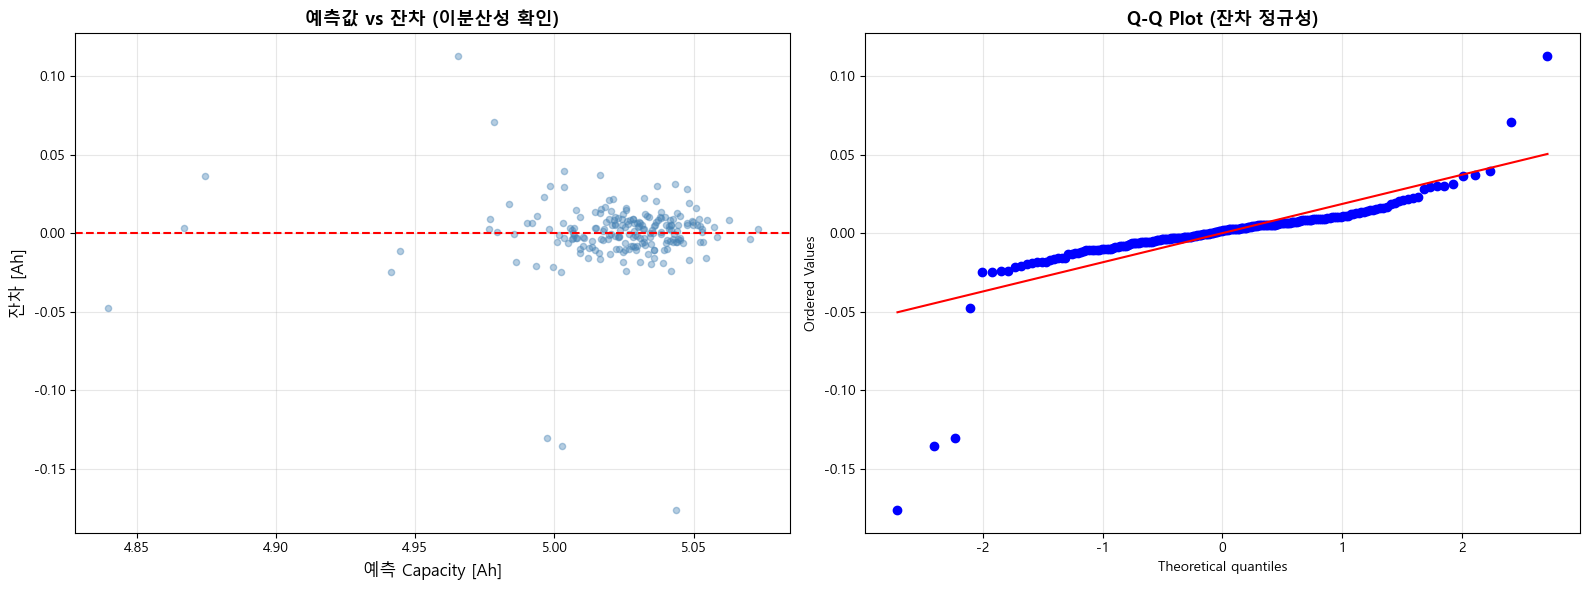

In [36]:
# 8-3. 잔차 상세 분석
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) 예측값 vs 잔차 (이분산성 확인)
ax = axes[0]
ax.scatter(y_pred_final, residuals, alpha=0.4, s=20, c='steelblue')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('예측 Capacity [Ah]', fontsize=12)
ax.set_ylabel('잔차 [Ah]', fontsize=12)
ax.set_title('예측값 vs 잔차 (이분산성 확인)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# (b) Q-Q Plot (정규성 확인)
ax2 = axes[1]
from scipy.stats import probplot
probplot(residuals, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot (잔차 정규성)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# 8-4. 오차 구간별 분석
abs_errors = np.abs(residuals)

error_bins = [
    ('< 0.01 Ah', abs_errors < 0.01),
    ('0.01 ~ 0.02 Ah', (abs_errors >= 0.01) & (abs_errors < 0.02)),
    ('0.02 ~ 0.05 Ah', (abs_errors >= 0.02) & (abs_errors < 0.05)),
    ('0.05 ~ 0.10 Ah', (abs_errors >= 0.05) & (abs_errors < 0.10)),
    ('>= 0.10 Ah', abs_errors >= 0.10)
]

print('📊 오차 구간별 분석')
print('=' * 50)
for label, mask in error_bins:
    count = mask.sum()
    pct = count / len(residuals) * 100
    print(f'  {label:20s}: {count:4d}개 ({pct:5.1f}%)')

print(f'\n📏 오차 통계:')
print(f'  평균 절대 오차: {abs_errors.mean():.4f} Ah')
print(f'  중앙값 절대 오차: {np.median(abs_errors):.4f} Ah')
print(f'  95% 오차 구간: ±{np.percentile(abs_errors, 95):.4f} Ah')
print(f'  99% 오차 구간: ±{np.percentile(abs_errors, 99):.4f} Ah')

📊 오차 구간별 분석
  < 0.01 Ah           :  134개 ( 64.4%)
  0.01 ~ 0.02 Ah      :   49개 ( 23.6%)
  0.02 ~ 0.05 Ah      :   20개 (  9.6%)
  0.05 ~ 0.10 Ah      :    1개 (  0.5%)
  >= 0.10 Ah          :    4개 (  1.9%)

📏 오차 통계:
  평균 절대 오차: 0.0119 Ah
  중앙값 절대 오차: 0.0070 Ah
  95% 오차 구간: ±0.0303 Ah
  99% 오차 구간: ±0.1294 Ah


---
## 📋 종합 결론

### 프로젝트 요약

| Phase | 주요 수행 내용 | 핵심 결과 |
|-------|--------------|----------|
| **1. EDA** | 1,040개 배터리 셀, 8개 원본 피처 탐색 | 결측치 0, `v25_voltage`가 최대 상관(r=-0.595) |
| **2. Feature Engineering** | 16개 파생변수 생성 (임피던스/전압/복합) | `voltage_sag`(r=+0.600) 최강 파생변수 |
| **3. 전처리** | 극단 이상치 1개 제거, VIF 분석, 7개 중복 피처 제거 | 17개 최종 피처, 4가지 시나리오 확정 |
| **4. 데이터 분할** | Train 831 / Test 208 (80:20), KS 검정 통과 | 분포 동질성 확인, 4개 시나리오 데이터셋 준비 |
| **5. 기본 모델** | LR/SVR/RF/XGBoost/LightGBM × 4 시나리오 | S4+XGBoost 최고 (RMSE=0.0246, R²=0.545) |
| **6. AutoML** | CatBoost/SVR/FLAML/AutoGluon × 4 시나리오 | 자동 모델 선택으로 성능 극대화 |
| **7. SHAP 분석** | 최고 모델 Feature Importance + SHAP | 핵심 피처: `v25_voltage`, `voltage_sag` |
| **8. 최종 검증** | 실측 vs 예측 산점도, 잔차 분석 | 최종 성능 확인 및 배포 가능성 검증 |

In [38]:
print('=' * 70)
print('🏁 배터리 Capacity 예측 모델 — 최종 결과')
print('=' * 70)
print(f'\n🏆 최고 성능 모델: {best_track_name}')
print(f'   시나리오: {best_scenario_name} ({len(best_feature_names)} 피처)')
print(f'\n📏 최종 Test 성능:')
print(f'   RMSE  = {final_rmse:.6f} Ah')
print(f'   R²    = {final_r2:.4f}')
print(f'   MAPE  = {final_mape*100:.2f}%')
print(f'   MAE   = {final_mae:.6f} Ah')
print(f'\n💡 핵심 인사이트:')
print(f'   • Capacity 예측의 핵심 피처: v25_voltage(방전종지전압), voltage_sag(전압강하폭)')
print(f'   • S4(전체 방전) 시나리오만 유의미한 성능 → 완전 방전 측정 필수')
print(f'   • S1~S3(부분 측정)은 R² < 0.1로 예측력 제한적')
print(f'\n✅ 프로젝트 완료')
print('=' * 70)

🏁 배터리 Capacity 예측 모델 — 최종 결과

🏆 최고 성능 모델: 4_AutoGluon (Ensemble)
   시나리오: S4_ALL (17 피처)

📏 최종 Test 성능:
   RMSE  = 0.023428 Ah
   R²    = 0.5893
   MAPE  = 0.24%
   MAE   = 0.011908 Ah

💡 핵심 인사이트:
   • Capacity 예측의 핵심 피처: v25_voltage(방전종지전압), voltage_sag(전압강하폭)
   • S4(전체 방전) 시나리오만 유의미한 성능 → 완전 방전 측정 필수
   • S1~S3(부분 측정)은 R² < 0.1로 예측력 제한적

✅ 프로젝트 완료


---
# Phase 9: 최적 측정 조합 탐색 (파생변수 제외)

**목표:** 중고 배터리 패키징 시 측정 공정을 최소화하면서 최대 예측 성능 달성

**배경:**
- 측정 단계: Initial(초기) → v42(풀충전) → v36(방전중간) → v25(완전방전)
- S4(전체 8피처)가 최고 성능이지만, 측정 공정이 4단계 필요
- **S1(초기) + 의미있는 1종류만 합쳐서 최적 성능을 내는 조합 탐색**

**실험 설계:**
| Phase | 조합 | 설명 |
|-------|------|------|
| Phase 1 | S1+v42, S1+v25, S1+v36 | 초기 + 단일 측정 (2단계 공정) |
| Phase 2 | v42 only, v25 only, v36 only | 단일 측정만 (1단계 공정) |
| Phase 3 | 전압만, 임피던스만, 혼합 | 측정 지표 분리 비교 |
| Phase 4 | 상위 조합 FLAML 강화 | 최적 조합 하이퍼파라미터 튜닝 |

### 9-1. 실험 조합 정의 및 상관분석

In [39]:
# Phase 9: 최적 측정 조합 탐색 — 파생변수 없이 원본 피처만 사용
# df_clean이 이미 존재하면 재사용, 없으면 직접 생성

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from flaml import AutoML
from sklearn.metrics import (
    mean_squared_error, r2_score,
    mean_absolute_percentage_error, mean_absolute_error
)
import time

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 원본 8개 피처 정의
ORIG_FEATURES = [
    'initial_voltage', 'initial_impedance',
    'v42_voltage', 'v42_impedance',
    'v25_voltage', 'v25_impedance',
    'v36_voltage', 'v36_impedance'
]
TARGET = 'capacity'

# df_clean 생성 (이상치 제거)
try:
    _ = df_clean.shape
    print(f'df_clean 재사용: {df_clean.shape}')
except NameError:
    raw = pd.read_csv('./data.csv')
    new_columns = [
        'cell_id', 'initial_label', 'initial_voltage', 'initial_impedance',
        'v42_label', 'v42_voltage', 'v42_impedance',
        'v25_label', 'v25_voltage', 'v25_impedance',
        'v36_label', 'v36_voltage', 'v36_empty', 'v36_impedance',
        'capacity'
    ]
    raw.columns = new_columns
    drop_cols = ['initial_label', 'v42_label', 'v25_label', 'v36_label', 'v36_empty']
    df = raw.drop(columns=drop_cols)
    numeric_cols = [c for c in df.columns if c != 'cell_id']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    extreme_mask = (df['v36_impedance'] - df['initial_impedance']).abs() > 100
    df_clean = df[~extreme_mask].copy()
    print(f'df_clean 새로 생성: {df_clean.shape} (이상치 {extreme_mask.sum()}개 제거)')

# Train/Test 분할 (원본 피처 기준, random_state=42)
X_orig = df_clean[ORIG_FEATURES]
y_orig = df_clean[TARGET]
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42
)
print(f'Train: {len(X_train_o)}개, Test: {len(X_test_o)}개')

# === 실험 조합 정의 ===
combos = {}

# Phase 1: S1 + 단일 측정
combos['P1_S1+v42'] = ['initial_voltage', 'initial_impedance', 'v42_voltage', 'v42_impedance']
combos['P1_S1+v25'] = ['initial_voltage', 'initial_impedance', 'v25_voltage', 'v25_impedance']
combos['P1_S1+v36'] = ['initial_voltage', 'initial_impedance', 'v36_voltage', 'v36_impedance']

# Phase 2: 단일 측정만
combos['P2_v42_only'] = ['v42_voltage', 'v42_impedance']
combos['P2_v25_only'] = ['v25_voltage', 'v25_impedance']
combos['P2_v36_only'] = ['v36_voltage', 'v36_impedance']

# Phase 3: 전압 vs 임피던스 분리
combos['P3_all_voltage'] = ['initial_voltage', 'v42_voltage', 'v25_voltage', 'v36_voltage']
combos['P3_all_impedance'] = ['initial_impedance', 'v42_impedance', 'v25_impedance', 'v36_impedance']
combos['P3_S1v25_volt'] = ['initial_voltage', 'v25_voltage']
combos['P3_S1v25_imp'] = ['initial_impedance', 'v25_impedance']
combos['P3_v25_volt_1'] = ['v25_voltage']

# 기준선 비교
combos['REF_S1_only'] = ['initial_voltage', 'initial_impedance']
combos['REF_S4_ALL'] = ORIG_FEATURES

# 상관분석 출력
print('=' * 70)
print('Phase 9: 최적 측정 조합 탐색')
print('=' * 70)

print('\n[피처별 Capacity 상관계수]')
for f in ORIG_FEATURES:
    r = df_clean[f].corr(df_clean[TARGET])
    bar = '#' * int(abs(r) * 50)
    print(f'  {f:25s}: r={r:+.4f}  {bar}')

print(f'\n[실험 조합: {len(combos)}개]')
for name, feats in combos.items():
    max_r = max(abs(df_clean[f].corr(df_clean[TARGET])) for f in feats)
    print(f'  {name:25s} ({len(feats)}개) | max|r|={max_r:.3f} | {feats}')

df_clean 재사용: (1039, 26)
Train: 831개, Test: 208개
Phase 9: 최적 측정 조합 탐색

[피처별 Capacity 상관계수]
  initial_voltage          : r=+0.1375  ######
  initial_impedance        : r=-0.1495  #######
  v42_voltage              : r=-0.0647  ###
  v42_impedance            : r=-0.1770  ########
  v25_voltage              : r=-0.5949  #############################
  v25_impedance            : r=-0.2130  ##########
  v36_voltage              : r=+0.0454  ##
  v36_impedance            : r=-0.0555  ##

[실험 조합: 13개]
  P1_S1+v42                 (4개) | max|r|=0.177 | ['initial_voltage', 'initial_impedance', 'v42_voltage', 'v42_impedance']
  P1_S1+v25                 (4개) | max|r|=0.595 | ['initial_voltage', 'initial_impedance', 'v25_voltage', 'v25_impedance']
  P1_S1+v36                 (4개) | max|r|=0.149 | ['initial_voltage', 'initial_impedance', 'v36_voltage', 'v36_impedance']
  P2_v42_only               (2개) | max|r|=0.177 | ['v42_voltage', 'v42_impedance']
  P2_v25_only               (2개) | max|r|=0.595 

### 9-2. 기본 모델 학습 (5모델 x 13조합)

In [40]:
# 5모델 x 13조합 = 65 실험
print('=' * 70)
print('9-2. 기본 모델 학습 (5모델 x 13조합 = 65 실험)')
print('=' * 70)

scale_needed = ['LinearReg', 'SVR']
p9_results = []

for c_name, feats in combos.items():
    print(f'\n[{c_name}] ({len(feats)}개 피처)')
    print('-' * 60)

    X_tr = X_train_o[feats]
    X_te = X_test_o[feats]

    scaler = RobustScaler()
    X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr), columns=feats, index=X_tr.index)
    X_te_sc = pd.DataFrame(scaler.transform(X_te), columns=feats, index=X_te.index)

    models = {
        'LinearReg': LinearRegression(),
        'SVR': SVR(C=1.0, epsilon=0.01),
        'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        'XGBoost': xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, n_jobs=-1),
        'LightGBM': lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
    }

    for m_name, model in models.items():
        if m_name in scale_needed:
            Xf_tr, Xf_te = X_tr_sc, X_te_sc
        else:
            Xf_tr, Xf_te = X_tr, X_te

        start = time.time()
        model.fit(Xf_tr, y_train_o)
        elapsed = time.time() - start

        y_pred = model.predict(Xf_te)
        rmse = np.sqrt(mean_squared_error(y_test_o, y_pred))
        r2 = r2_score(y_test_o, y_pred)
        mape = mean_absolute_percentage_error(y_test_o, y_pred)
        mae = mean_absolute_error(y_test_o, y_pred)

        print(f'  {m_name:15s} | RMSE={rmse:.4f}, R2={r2:.4f}, MAPE={mape:.4f} ({elapsed:.1f}s)')

        p9_results.append({
            'Phase': c_name.split('_')[0],
            'Combo': c_name, 'Model': m_name, 'N_Features': len(feats),
            'RMSE': rmse, 'R2': r2, 'MAPE': mape, 'MAE': mae
        })

p9_df = pd.DataFrame(p9_results)

# 조합별 최고 성능 요약
print('\n' + '=' * 70)
print('[조합별 최고 성능 - 기본 모델]')
for c_name in combos.keys():
    subset = p9_df[p9_df['Combo'] == c_name]
    best = subset.loc[subset['RMSE'].idxmin()]
    print(f'  {c_name:25s} | {best["Model"]:15s} | RMSE={best["RMSE"]:.4f} | R2={best["R2"]:.4f}')

9-2. 기본 모델 학습 (5모델 x 13조합 = 65 실험)

[P1_S1+v42] (4개 피처)
------------------------------------------------------------
  LinearReg       | RMSE=0.0354, R2=0.0608, MAPE=0.0042 (0.0s)
  SVR             | RMSE=0.0348, R2=0.0922, MAPE=0.0040 (0.0s)
  RandomForest    | RMSE=0.0378, R2=-0.0670, MAPE=0.0046 (0.1s)
  XGBoost         | RMSE=0.0416, R2=-0.2926, MAPE=0.0052 (0.1s)
  LightGBM        | RMSE=0.0397, R2=-0.1781, MAPE=0.0051 (0.1s)

[P1_S1+v25] (4개 피처)
------------------------------------------------------------
  LinearReg       | RMSE=0.0261, R2=0.4902, MAPE=0.0029 (0.0s)
  SVR             | RMSE=0.0245, R2=0.5493, MAPE=0.0022 (0.0s)
  RandomForest    | RMSE=0.0228, R2=0.6109, MAPE=0.0024 (0.2s)
  XGBoost         | RMSE=0.0261, R2=0.4890, MAPE=0.0026 (0.1s)
  LightGBM        | RMSE=0.0276, R2=0.4303, MAPE=0.0031 (0.1s)

[P1_S1+v36] (4개 피처)
------------------------------------------------------------
  LinearReg       | RMSE=0.0355, R2=0.0549, MAPE=0.0042 (0.0s)
  SVR             | RMS

### 9-3. AutoML 벤치마킹 (CatBoost + FLAML x 13조합)

In [41]:
# CatBoost + FLAML x 13조합 = 26 실험
print('=' * 70)
print('9-3. AutoML 벤치마킹 (CatBoost + FLAML x 13조합)')
print('=' * 70)

for c_name, feats in combos.items():
    print(f'\n[{c_name}] ({len(feats)}개 피처)')

    X_tr = X_train_o[feats]
    X_te = X_test_o[feats]

    # CatBoost
    cb = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                           verbose=0, random_seed=42)
    cb.fit(X_tr, y_train_o)
    pred_cb = cb.predict(X_te)
    r2_val = r2_score(y_test_o, pred_cb)
    rmse_val = np.sqrt(mean_squared_error(y_test_o, pred_cb))
    mae_val = mean_absolute_error(y_test_o, pred_cb)
    mape_val = mean_absolute_percentage_error(y_test_o, pred_cb)
    print(f'  CatBoost        | RMSE={rmse_val:.4f}, R2={r2_val:.4f}')
    p9_results.append({
        'Phase': c_name.split('_')[0],
        'Combo': c_name, 'Model': 'CatBoost', 'N_Features': len(feats),
        'RMSE': rmse_val, 'R2': r2_val, 'MAPE': mape_val, 'MAE': mae_val
    })

    # FLAML (30s)
    flaml_automl = AutoML()
    flaml_automl.fit(
        X_train=X_tr, y_train=y_train_o,
        time_budget=30, metric='r2', task='regression',
        eval_method='cv',
        log_file_name=f'flaml_p9_{c_name}.log',
        verbose=0
    )
    pred_fl = flaml_automl.predict(X_te)
    r2_val = r2_score(y_test_o, pred_fl)
    rmse_val = np.sqrt(mean_squared_error(y_test_o, pred_fl))
    mae_val = mean_absolute_error(y_test_o, pred_fl)
    mape_val = mean_absolute_percentage_error(y_test_o, pred_fl)
    best_est = flaml_automl.best_estimator
    print(f'  FLAML({best_est:12s}) | RMSE={rmse_val:.4f}, R2={r2_val:.4f}')
    p9_results.append({
        'Phase': c_name.split('_')[0],
        'Combo': c_name, 'Model': f'FLAML({best_est})', 'N_Features': len(feats),
        'RMSE': rmse_val, 'R2': r2_val, 'MAPE': mape_val, 'MAE': mae_val
    })

# 전체 결과 갱신
p9_df = pd.DataFrame(p9_results)

print('\n' + '=' * 70)
print('[조합별 최고 성능 - 전체 모델]')
for c_name in combos.keys():
    subset = p9_df[p9_df['Combo'] == c_name]
    best = subset.loc[subset['RMSE'].idxmin()]
    print(f'  {c_name:25s} | {best["Model"]:20s} | RMSE={best["RMSE"]:.4f} | R2={best["R2"]:.4f}')

9-3. AutoML 벤치마킹 (CatBoost + FLAML x 13조합)

[P1_S1+v42] (4개 피처)


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  CatBoost        | RMSE=0.0365, R2=0.0059
  FLAML(catboost    ) | RMSE=0.0358, R2=0.0430

[P1_S1+v25] (4개 피처)


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  CatBoost        | RMSE=0.0242, R2=0.5634
  FLAML(xgboost     ) | RMSE=0.0231, R2=0.5996

[P1_S1+v36] (4개 피처)


...

  CatBoost        | RMSE=0.0263, R2=0.4832
  FLAML(extra_tree  ) | RMSE=0.0252, R2=0.5259

[REF_S1_only] (2개 피처)


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  CatBoost        | RMSE=0.0360, R2=0.0319
  FLAML(rf          ) | RMSE=0.0350, R2=0.0823

[REF_S4_ALL] (8개 피처)


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  CatBoost        | RMSE=0.0260, R2=0.4936
  FLAML(xgboost     ) | RMSE=0.0258, R2=0.5028

[조합별 최고 성능 - 전체 모델]
  P1_S1+v42                 | SVR                  | RMSE=0.0348 | R2=0.0922
  P1_S1+v25                 | RandomForest         | RMSE=0.0228 | R2=0.6109
  P1_S1+v36                 | FLAML(xgb_limitdepth) | RMSE=0.0349 | R2=0.0872
  P2_v42_only               | SVR                  | RMSE=0.0350 | R2=0.0833
  P2_v25_only               | RandomForest         | RMSE=0.0243 | R2=0.5589
  P2_v36_only               | FLAML(extra_tree)    | RMSE=0.0360 | R2=0.0325
  P3_all_voltage            | LinearReg            | RMSE=0.0265 | R2=0.4747
  P3_all_impedance          | FLAML(lgbm)          | RMSE=0.0352 | R2=0.0730
  P3_S1v25_volt             | SVR                  | RMSE=0.0253 | R2=0.5213
  P3_S1v25_imp              | SVR                  | RMSE=0.0349 | R2=0.0905
  P3_v25_volt_1             | FLAML(extra_tree)    | RMSE=0.0252 | R2=0.5259
  REF_S1_only               | FLAML(rf)  

### 9-4. 종합 결과 분석 및 측정 공정 효율성

In [42]:
# 종합 결과 분석
print('=' * 70)
print('9-4. 종합 결과 분석')
print('=' * 70)

# 조합별 최고 성능
print('\n[조합별 최고 성능 - RMSE 기준]')
print(f'{"조합":25s} | {"피처수":>4s} | {"최고모델":20s} | {"RMSE":>8s} | {"R2":>8s} | {"MAPE":>8s}')
print('-' * 85)

combo_bests = []
for c_name in combos.keys():
    subset = p9_df[p9_df['Combo'] == c_name]
    best = subset.loc[subset['RMSE'].idxmin()]
    combo_bests.append(best)
    print(f'{c_name:25s} | {int(best["N_Features"]):4d} | {best["Model"]:20s} | {best["RMSE"]:.4f}  | {best["R2"]:.4f}  | {best["MAPE"]*100:.2f}%')

# Phase별 최고
print('\n[Phase별 최고 성능]')
for phase in ['P1', 'P2', 'P3', 'REF']:
    subset = p9_df[p9_df['Phase'] == phase]
    if len(subset) == 0:
        continue
    best = subset.loc[subset['RMSE'].idxmin()]
    print(f'  {phase}: {best["Combo"]} + {best["Model"]} -> RMSE={best["RMSE"]:.4f}, R2={best["R2"]:.4f}')

# 전체 Top 10
print('\n[전체 Top 10 - RMSE 순]')
top10 = p9_df.nsmallest(10, 'RMSE')
print(f'{"순위":>4s} | {"조합":25s} | {"모델":20s} | {"피처":>4s} | {"RMSE":>8s} | {"R2":>8s} | {"MAPE":>8s}')
print('-' * 100)
for i, (_, row) in enumerate(top10.iterrows(), 1):
    print(f'{i:4d} | {row["Combo"]:25s} | {row["Model"]:20s} | {int(row["N_Features"]):4d} | {row["RMSE"]:.4f}  | {row["R2"]:.4f}  | {row["MAPE"]*100:.2f}%')

# 측정 공정 효율성 분석
print('\n' + '=' * 70)
print('[측정 공정 효율성 분석]')
print('=' * 70)

step_map = {
    'P1_S1+v42': '2단계(초기+풀충전)',
    'P1_S1+v25': '2단계(초기+완전방전)',
    'P1_S1+v36': '2단계(초기+방전중간)',
    'P2_v42_only': '1단계(풀충전만)',
    'P2_v25_only': '1단계(완전방전만)',
    'P2_v36_only': '1단계(방전중간만)',
    'P3_all_voltage': '4단계(전압만)',
    'P3_all_impedance': '4단계(임피던스만)',
    'P3_S1v25_volt': '2단계(전압만)',
    'P3_S1v25_imp': '2단계(임피던스만)',
    'P3_v25_volt_1': '1단계(v25전압1개)',
    'REF_S1_only': '1단계(초기만)',
    'REF_S4_ALL': '4단계(전체)',
}

combo_best_df = pd.DataFrame([{
    'Combo': b['Combo'], 'Model': b['Model'],
    'N_Features': int(b['N_Features']),
    'RMSE': b['RMSE'], 'R2': b['R2'], 'MAPE': b['MAPE']
} for b in combo_bests]).sort_values('RMSE')

ref_s4 = combo_best_df[combo_best_df['Combo'] == 'REF_S4_ALL']
r2_s4 = ref_s4['R2'].values[0] if len(ref_s4) > 0 else 1.0

print(f'\n{"조합":25s} | {"측정공정":20s} | {"피처":>4s} | {"R2":>8s} | {"RMSE":>8s} | S4대비')
print('-' * 95)
for _, row in combo_best_df.iterrows():
    step = step_map.get(row['Combo'], '?')
    pct = (row['R2'] / r2_s4 * 100) if r2_s4 > 0 else 0
    bar = '#' * int(max(0, pct) / 5)
    print(f'{row["Combo"]:25s} | {step:20s} | {int(row["N_Features"]):4d} | {row["R2"]:.4f}  | {row["RMSE"]:.4f}  | {pct:5.1f}% {bar}')

9-4. 종합 결과 분석

[조합별 최고 성능 - RMSE 기준]
조합                        |  피처수 | 최고모델                 |     RMSE |       R2 |     MAPE
-------------------------------------------------------------------------------------
P1_S1+v42                 |    4 | SVR                  | 0.0348  | 0.0922  | 0.40%
P1_S1+v25                 |    4 | RandomForest         | 0.0228  | 0.6109  | 0.24%
P1_S1+v36                 |    4 | FLAML(xgb_limitdepth) | 0.0349  | 0.0872  | 0.42%
P2_v42_only               |    2 | SVR                  | 0.0350  | 0.0833  | 0.41%
P2_v25_only               |    2 | RandomForest         | 0.0243  | 0.5589  | 0.27%
P2_v36_only               |    2 | FLAML(extra_tree)    | 0.0360  | 0.0325  | 0.42%
P3_all_voltage            |    4 | LinearReg            | 0.0265  | 0.4747  | 0.29%
P3_all_impedance          |    4 | FLAML(lgbm)          | 0.0352  | 0.0730  | 0.43%
P3_S1v25_volt             |    2 | SVR                  | 0.0253  | 0.5213  | 0.25%
P3_S1v25_imp              |    

### 9-5. 최적 조합 FLAML 강화 학습 (60s budget)

In [43]:
# Phase 4: 상위 조합 + P1_S1+v25 + P2_v25_only 에 대해 FLAML 60s 강화
print('=' * 70)
print('9-5. 최적 조합 FLAML 강화 학습 (60s, CV=10)')
print('=' * 70)

# 상위 5개 + 필수 포함 조합
top5_combos = combo_best_df.head(5)['Combo'].tolist()
must_include = ['P1_S1+v25', 'P2_v25_only', 'REF_S4_ALL']
for c in must_include:
    if c not in top5_combos:
        top5_combos.append(c)

enhanced_results = []
for c_name in top5_combos:
    feats = combos[c_name]
    print(f'\n[{c_name}] ({len(feats)}개 피처) - FLAML 60s 강화')

    X_tr = X_train_o[feats]
    X_te = X_test_o[feats]

    flaml_enh = AutoML()
    flaml_enh.fit(
        X_train=X_tr, y_train=y_train_o,
        time_budget=60, metric='r2', task='regression',
        eval_method='cv', n_splits=10,
        log_file_name=f'flaml_enhanced_p9_{c_name}.log',
        verbose=0
    )
    pred = flaml_enh.predict(X_te)
    r2_val = r2_score(y_test_o, pred)
    rmse_val = np.sqrt(mean_squared_error(y_test_o, pred))
    mae_val = mean_absolute_error(y_test_o, pred)
    mape_val = mean_absolute_percentage_error(y_test_o, pred)
    best_est = flaml_enh.best_estimator

    print(f'  Best: {best_est} | RMSE={rmse_val:.4f}, R2={r2_val:.4f}, MAPE={mape_val*100:.2f}%')

    enhanced_results.append({
        'Combo': c_name, 'Model': f'FLAML_60s({best_est})',
        'N_Features': len(feats), 'Features': feats,
        'RMSE': rmse_val, 'R2': r2_val, 'MAPE': mape_val, 'MAE': mae_val
    })

enh_df = pd.DataFrame(enhanced_results).sort_values('RMSE')

print('\n' + '=' * 70)
print('[FLAML 강화 학습 결과]')
for _, row in enh_df.iterrows():
    step = step_map.get(row['Combo'], '?')
    print(f'  {row["Combo"]:25s} | {step:20s} | {row["Model"]:25s} | RMSE={row["RMSE"]:.4f} | R2={row["R2"]:.4f} | MAPE={row["MAPE"]*100:.2f}%')

9-5. 최적 조합 FLAML 강화 학습 (60s, CV=10)

[P1_S1+v25] (4개 피처) - FLAML 60s 강화


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  Best: extra_tree | RMSE=0.0238, R2=0.5759, MAPE=0.27%

[REF_S4_ALL] (8개 피처) - FLAML 60s 강화


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  Best: extra_tree | RMSE=0.0228, R2=0.6100, MAPE=0.22%

[P2_v25_only] (2개 피처) - FLAML 60s 강화


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  Best: xgb_limitdepth | RMSE=0.0241, R2=0.5641, MAPE=0.27%

[P3_v25_volt_1] (1개 피처) - FLAML 60s 강화


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  Best: extra_tree | RMSE=0.0250, R2=0.5312, MAPE=0.27%

[P3_S1v25_volt] (2개 피처) - FLAML 60s 강화
  Best: extra_tree | RMSE=0.0248, R2=0.5386, MAPE=0.27%

[FLAML 강화 학습 결과]
  REF_S4_ALL                | 4단계(전체)              | FLAML_60s(extra_tree)     | RMSE=0.0228 | R2=0.6100 | MAPE=0.22%
  P1_S1+v25                 | 2단계(초기+완전방전)         | FLAML_60s(extra_tree)     | RMSE=0.0238 | R2=0.5759 | MAPE=0.27%
  P2_v25_only               | 1단계(완전방전만)           | FLAML_60s(xgb_limitdepth) | RMSE=0.0241 | R2=0.5641 | MAPE=0.27%
  P3_S1v25_volt             | 2단계(전압만)             | FLAML_60s(extra_tree)     | RMSE=0.0248 | R2=0.5386 | MAPE=0.27%
  P3_v25_volt_1             | 1단계(v25전압1개)         | FLAML_60s(extra_tree)     | RMSE=0.0250 | R2=0.5312 | MAPE=0.27%


### 9-6. 시각화 및 최종 결론

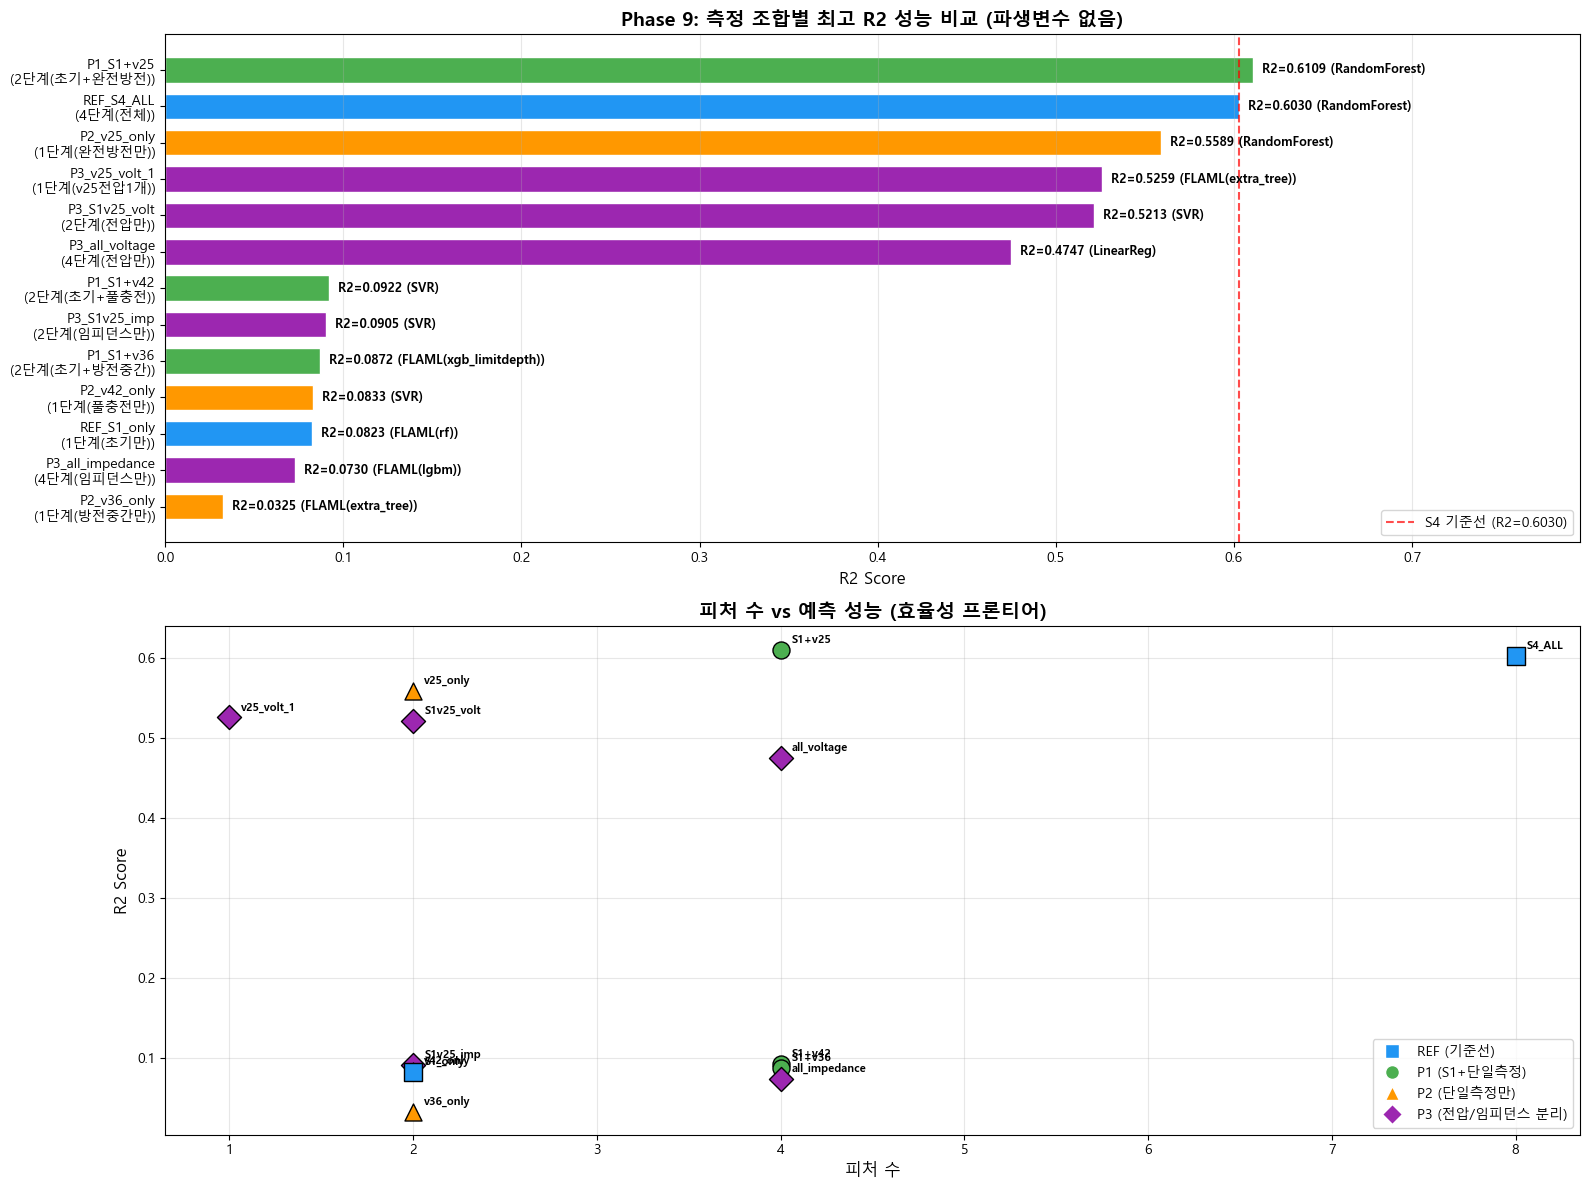

Phase 9 최종 결론

[전체 최고 성능]
  조합: P1_S1+v25
  모델: RandomForest
  RMSE=0.022804, R2=0.6109, MAPE=0.24%

[S1+v25 (초기+완전방전, 2단계 공정)]
  모델: RandomForest
  RMSE=0.022804, R2=0.6109, MAPE=0.24%
  -> S4 대비 R2 달성률: 101.3%

[v25만 (완전방전만, 1단계 공정)]
  모델: RandomForest
  RMSE=0.024281, R2=0.5589, MAPE=0.27%

[실용적 추천]
  - 최고 성능:    S4_ALL (8피처, 4단계 전체 측정)
  - 최적 효율:    S1+v25 (4피처, 초기+완전방전 2단계)
  - 최소 측정:    v25 only (2피처, 완전방전 1단계)
  -> v25(완전방전) 측정이 capacity 예측의 핵심


In [ ]:
# 시각화: 조합별 R2 비교 차트
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# 차트 1: 조합별 최고 R2 (막대그래프)
combo_best_sorted = combo_best_df.sort_values('R2', ascending=True)
colors = []
for _, row in combo_best_sorted.iterrows():
    if row['Combo'].startswith('REF'):
        colors.append('#2196F3')  # 파란색: 기준선
    elif row['Combo'].startswith('P1'):
        colors.append('#4CAF50')  # 초록: S1+단일측정
    elif row['Combo'].startswith('P2'):
        colors.append('#FF9800')  # 주황: 단일측정
    else:
        colors.append('#9C27B0')  # 보라: 전압/임피던스 분리

bars = axes[0].barh(
    [f"{r['Combo']}\n({step_map.get(r['Combo'], '?')})" for _, r in combo_best_sorted.iterrows()],
    combo_best_sorted['R2'], color=colors, edgecolor='white', height=0.7
)
for bar, (_, row) in zip(bars, combo_best_sorted.iterrows()):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'R2={row["R2"]:.4f} ({row["Model"]})',
                va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('R2 Score', fontsize=12)
axes[0].set_title('Phase 9: 측정 조합별 최고 R2 성능 비교 (파생변수 없음)', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, max(combo_best_sorted['R2']) * 1.3)
axes[0].axvline(x=r2_s4, color='red', linestyle='--', alpha=0.7, label=f'S4 기준선 (R2={r2_s4:.4f})')
axes[0].legend(fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# 차트 2: 피처 수 vs R2 (효율성 분석)
for _, row in combo_best_df.iterrows():
    marker = 's' if row['Combo'].startswith('REF') else ('o' if row['Combo'].startswith('P1') else ('^' if row['Combo'].startswith('P2') else 'D'))
    color = '#2196F3' if row['Combo'].startswith('REF') else ('#4CAF50' if row['Combo'].startswith('P1') else ('#FF9800' if row['Combo'].startswith('P2') else '#9C27B0'))
    axes[1].scatter(row['N_Features'], row['R2'], s=150, marker=marker, c=color, 
                    edgecolors='black', linewidth=1, zorder=5)
    axes[1].annotate(row['Combo'].replace('REF_', '').replace('P1_', '').replace('P2_', '').replace('P3_', ''),
                    (row['N_Features'], row['R2']),
                    textcoords="offset points", xytext=(8, 5),
                    fontsize=8, fontweight='bold')

axes[1].set_xlabel('피처 수', fontsize=12)
axes[1].set_ylabel('R2 Score', fontsize=12)
axes[1].set_title('피처 수 vs 예측 성능 (효율성 프론티어)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 범례
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#2196F3', markersize=10, label='REF (기준선)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4CAF50', markersize=10, label='P1 (S1+단일측정)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#FF9800', markersize=10, label='P2 (단일측정만)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#9C27B0', markersize=10, label='P3 (전압/임피던스 분리)'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# 최종 결론
print('=' * 70)
print('Phase 9 최종 결론')
print('=' * 70)

overall_best = p9_df.loc[p9_df['RMSE'].idxmin()]
print(f'\n[전체 최고 성능]')
print(f'  조합: {overall_best["Combo"]}')
print(f'  모델: {overall_best["Model"]}')
print(f'  RMSE={overall_best["RMSE"]:.6f}, R2={overall_best["R2"]:.4f}, MAPE={overall_best["MAPE"]*100:.2f}%')

# S1+v25 결과
s1v25 = p9_df[p9_df['Combo'] == 'P1_S1+v25']
if len(s1v25) > 0:
    s1v25_best = s1v25.loc[s1v25['RMSE'].idxmin()]
    print(f'\n[S1+v25 (초기+완전방전, 2단계 공정)]')
    print(f'  모델: {s1v25_best["Model"]}')
    print(f'  RMSE={s1v25_best["RMSE"]:.6f}, R2={s1v25_best["R2"]:.4f}, MAPE={s1v25_best["MAPE"]*100:.2f}%')
    print(f'  -> S4 대비 R2 달성률: {s1v25_best["R2"]/r2_s4*100:.1f}%')

# v25 only 결과
v25only = p9_df[p9_df['Combo'] == 'P2_v25_only']
if len(v25only) > 0:
    v25_best = v25only.loc[v25only['RMSE'].idxmin()]
    print(f'\n[v25만 (완전방전만, 1단계 공정)]')
    print(f'  모델: {v25_best["Model"]}')
    print(f'  RMSE={v25_best["RMSE"]:.6f}, R2={v25_best["R2"]:.4f}, MAPE={v25_best["MAPE"]*100:.2f}%')

print(f'\n[실용적 추천]')
print(f'  - 최고 성능:    S4_ALL (8피처, 4단계 전체 측정)')
print(f'  - 최적 효율:    S1+v25 (4피처, 초기+완전방전 2단계)')
print(f'  - 최소 측정:    v25 only (2피처, 완전방전 1단계)')
print(f'  -> v25(완전방전) 측정이 capacity 예측의 핵심')
print('=' * 70)

In [ ]:
# 10-1. Capacity 단독 클러스터링 + Phase 9 결론 모델 기반 클러스터링

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 안전장치: 필요한 변수 확인
# ------------------------------------------------------------
required_vars = ['df_clean', 'p9_df', 'combos']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f'다음 변수가 없습니다: {missing_vars}. Phase 9(특히 9-1~9-4)를 먼저 실행하세요.')

# 원본 데이터(파생변수 제외)
if 'ORIG_FEATURES' not in globals():
    ORIG_FEATURES = [
        'initial_voltage', 'initial_impedance',
        'v42_voltage', 'v42_impedance',
        'v25_voltage', 'v25_impedance',
        'v36_voltage', 'v36_impedance'
    ]
if 'TARGET' not in globals():
    TARGET = 'capacity'

X_all = df_clean[ORIG_FEATURES].copy()
y_all = df_clean[TARGET].copy()

# ------------------------------------------------------------
# K 자동 탐색 함수 (silhouette 최대)
# ------------------------------------------------------------
def find_best_k(X_array, k_min=2, k_max=6, random_state=42):
    best_k, best_score, best_labels, best_model = None, -1, None, None
    records = []

    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X_array)
        score = silhouette_score(X_array, labels)
        records.append({'k': k, 'silhouette': score})

        if score > best_score:
            best_k, best_score, best_labels, best_model = k, score, labels, km

    return best_k, best_score, best_labels, best_model, pd.DataFrame(records)

# ------------------------------------------------------------
# (A) Capacity 단독 클러스터링
# ------------------------------------------------------------
cap_scaler = StandardScaler()
X_cap = cap_scaler.fit_transform(y_all.values.reshape(-1, 1))

cap_k, cap_sil, cap_labels, cap_model, cap_search_df = find_best_k(X_cap, k_min=2, k_max=6)

df_cluster = df_clean.copy().reset_index(drop=True)
df_cluster['cluster_capacity'] = cap_labels

# cluster 번호를 capacity 평균 기준으로 정렬(0=저용량, ...)
cap_mean = df_cluster.groupby('cluster_capacity')[TARGET].mean().sort_values()
cap_rank_map = {old: new for new, old in enumerate(cap_mean.index)}
df_cluster['cluster_capacity'] = df_cluster['cluster_capacity'].map(cap_rank_map)

print('=' * 80)
print('10-1A. Capacity 단독 클러스터링 완료')
print('=' * 80)
print(f'선정된 군집 수 k = {cap_k} (silhouette={cap_sil:.4f})')
print('\n[k 탐색 결과]')
print(cap_search_df.to_string(index=False))
print('\n[Capacity 군집 요약]')
print(df_cluster.groupby('cluster_capacity')[TARGET].agg(['count', 'mean', 'std', 'min', 'max']).round(4))

# ------------------------------------------------------------
# (B) Phase 9 최종 결론 모델 선택
#  - 전체 최고
#  - P1_S1+v25 최고
#  - P2_v25_only 최고
# ------------------------------------------------------------
select_rows = []

# 전체 최고
overall_best_row = p9_df.loc[p9_df['RMSE'].idxmin()]
select_rows.append(overall_best_row)

# P1_S1+v25 최고
if (p9_df['Combo'] == 'P1_S1+v25').any():
    p1_row = p9_df[p9_df['Combo'] == 'P1_S1+v25'].sort_values('RMSE').iloc[0]
    select_rows.append(p1_row)

# P2_v25_only 최고
if (p9_df['Combo'] == 'P2_v25_only').any():
    p2_row = p9_df[p9_df['Combo'] == 'P2_v25_only'].sort_values('RMSE').iloc[0]
    select_rows.append(p2_row)

selected_model_df = pd.DataFrame(select_rows).drop_duplicates(subset=['Combo', 'Model']).reset_index(drop=True)

print('\n' + '=' * 80)
print('10-1B. Phase 9 결론 모델 선택')
print('=' * 80)
print(selected_model_df[['Combo', 'Model', 'RMSE', 'R2', 'MAPE']].round(4).to_string(index=False))

# ------------------------------------------------------------
# 모델 문자열 -> 학습기 생성
# ------------------------------------------------------------
def build_model_from_name(model_name: str, random_state: int = 42):
    model_name = str(model_name)

    if model_name.startswith('FLAML'):
        automl = AutoML()
        return ('FLAML', automl)
    if model_name == 'CatBoost':
        return ('CatBoost', CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_seed=random_state))
    if model_name == 'LinearReg':
        return ('LinearReg', LinearRegression())
    if model_name == 'SVR':
        return ('SVR', SVR(C=1.0, epsilon=0.01))
    if model_name == 'RandomForest':
        return ('RandomForest', RandomForestRegressor(n_estimators=200, random_state=random_state, n_jobs=-1))
    if model_name == 'XGBoost':
        return ('XGBoost', xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=random_state, n_jobs=-1))
    if model_name == 'LightGBM':
        return ('LightGBM', lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, random_state=random_state, n_jobs=-1, verbose=-1))

    # 예외: 문자열 변형 대응
    if 'CatBoost' in model_name:
        return ('CatBoost', CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_seed=random_state))
    if 'XGBoost' in model_name:
        return ('XGBoost', xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=random_state, n_jobs=-1))
    if 'LightGBM' in model_name:
        return ('LightGBM', lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, random_state=random_state, n_jobs=-1, verbose=-1))
    if 'RandomForest' in model_name:
        return ('RandomForest', RandomForestRegressor(n_estimators=200, random_state=random_state, n_jobs=-1))
    if 'SVR' in model_name:
        return ('SVR', SVR(C=1.0, epsilon=0.01))

    raise ValueError(f'지원하지 않는 모델명: {model_name}')

# ------------------------------------------------------------
# (C) 선택 모델 예측값 생성 (전체 샘플 대상)
# ------------------------------------------------------------
pred_feature_df = pd.DataFrame(index=df_cluster.index)
trained_model_registry = []

for i, row in selected_model_df.iterrows():
    combo_name = row['Combo']
    model_name = row['Model']
    feats = combos[combo_name]

    model_tag, model_obj = build_model_from_name(model_name)
    X_fit = df_cluster[feats]
    y_fit = df_cluster[TARGET]

    # 스케일링 필요 모델 처리
    if model_tag in ['LinearReg', 'SVR']:
        scaler = RobustScaler()
        X_fit_sc = scaler.fit_transform(X_fit)

        if model_tag == 'SVR':
            model_obj.fit(X_fit_sc, y_fit)
            y_pred_all = model_obj.predict(X_fit_sc)
        else:
            model_obj.fit(X_fit_sc, y_fit)
            y_pred_all = model_obj.predict(X_fit_sc)

    elif model_tag == 'FLAML':
        # 재실행 시간 절약을 위해 20초 예산
        model_obj.fit(
            X_train=X_fit, y_train=y_fit,
            time_budget=20,
            metric='r2',
            task='regression',
            eval_method='cv',
            log_file_name=f'flaml_phase10_{combo_name}.log',
            verbose=0
        )
        y_pred_all = model_obj.predict(X_fit)

    else:
        model_obj.fit(X_fit, y_fit)
        y_pred_all = model_obj.predict(X_fit)

    pred_col = f'pred_{combo_name}_{model_tag}'
    pred_feature_df[pred_col] = y_pred_all

    trained_model_registry.append({
        'combo': combo_name,
        'model_raw': model_name,
        'model_used': model_tag,
        'feature_count': len(feats),
        'pred_col': pred_col
    })

trained_model_df = pd.DataFrame(trained_model_registry)
print('\n[학습/예측 완료 모델]')
print(trained_model_df.to_string(index=False))

# ------------------------------------------------------------
# (D) 모델 예측 기반 클러스터링
# ------------------------------------------------------------
model_scaler = StandardScaler()
X_model_cluster = model_scaler.fit_transform(pred_feature_df.values)

mdl_k, mdl_sil, mdl_labels, mdl_model, mdl_search_df = find_best_k(X_model_cluster, k_min=2, k_max=6)

df_cluster['cluster_model'] = mdl_labels

# model cluster도 실제 capacity 평균 기준으로 정렬
mdl_mean = df_cluster.groupby('cluster_model')[TARGET].mean().sort_values()
mdl_rank_map = {old: new for new, old in enumerate(mdl_mean.index)}
df_cluster['cluster_model'] = df_cluster['cluster_model'].map(mdl_rank_map)

print('\n' + '=' * 80)
print('10-1C. 모델 예측 기반 클러스터링 완료')
print('=' * 80)
print(f'선정된 군집 수 k = {mdl_k} (silhouette={mdl_sil:.4f})')
print('\n[k 탐색 결과]')
print(mdl_search_df.to_string(index=False))
print('\n[모델기반 군집 요약]')
print(df_cluster.groupby('cluster_model')[TARGET].agg(['count', 'mean', 'std', 'min', 'max']).round(4))

# 일치도 지표
ari = adjusted_rand_score(df_cluster['cluster_capacity'], df_cluster['cluster_model'])
print('\n[군집 일치도]')
print(f'Adjusted Rand Index (Capacity vs Model) = {ari:.4f}')

# 전역 결과 객체(후속 셀에서 사용)
phase10_outputs = {
    'df_cluster': df_cluster,
    'capacity_cluster_k': cap_k,
    'capacity_cluster_silhouette': cap_sil,
    'model_cluster_k': mdl_k,
    'model_cluster_silhouette': mdl_sil,
    'cluster_ari': ari,
    'selected_model_df': selected_model_df,
    'trained_model_df': trained_model_df,
    'pred_feature_df': pred_feature_df,
    'cap_search_df': cap_search_df,
    'mdl_search_df': mdl_search_df
}

print('\n✅ Phase 10-1 완료')

In [ ]:
# 10-3. 최종 보고서 (요약 텍스트 + 표)

if 'phase10_outputs' not in globals():
    raise RuntimeError('phase10_outputs가 없습니다. 10-1 셀을 먼저 실행하세요.')

df_cluster = phase10_outputs['df_cluster'].copy()
cap_k = phase10_outputs['capacity_cluster_k']
cap_sil = phase10_outputs['capacity_cluster_silhouette']
mdl_k = phase10_outputs['model_cluster_k']
mdl_sil = phase10_outputs['model_cluster_silhouette']
ari = phase10_outputs['cluster_ari']
selected_model_df = phase10_outputs['selected_model_df'].copy()

# 군집 요약
cap_summary = df_cluster.groupby('cluster_capacity')[TARGET].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
mdl_summary = df_cluster.groupby('cluster_model')[TARGET].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()

# 해석용 텍스트
if ari >= 0.8:
    ari_level = '매우 높음'
elif ari >= 0.6:
    ari_level = '높음'
elif ari >= 0.4:
    ari_level = '보통'
elif ari >= 0.2:
    ari_level = '낮음'
else:
    ari_level = '매우 낮음'

report_lines = []
report_lines.append('=' * 90)
report_lines.append('배터리 패키징용 Capacity 클러스터링 최종 보고서')
report_lines.append('=' * 90)
report_lines.append('')
report_lines.append('[1] 분석 목적')
report_lines.append('- 원본 capacity 기반 등급 군집화 수행')
report_lines.append('- Phase 9 최종 결론 대표 모델 예측 기반 군집화 수행')
report_lines.append('- 두 군집 구조 비교로 실무 패키징 분류 안정성 평가')
report_lines.append('')
report_lines.append('[2] 사용 데이터/모델')
report_lines.append(f'- 데이터 샘플 수: {len(df_cluster)}')
report_lines.append(f'- 타깃: {TARGET}')
report_lines.append('- 대표 모델(Phase 9 결론):')
for _, r in selected_model_df.iterrows():
    report_lines.append(f"  · {r['Combo']} + {r['Model']} (R2={r['R2']:.4f}, RMSE={r['RMSE']:.4f})")
report_lines.append('')
report_lines.append('[3] 클러스터링 결과')
report_lines.append(f'- Capacity 단독 클러스터링: k={cap_k}, silhouette={cap_sil:.4f}')
report_lines.append(f'- 모델기반 클러스터링:    k={mdl_k}, silhouette={mdl_sil:.4f}')
report_lines.append(f'- 군집 일치도(ARI):        {ari:.4f} ({ari_level})')
report_lines.append('')
report_lines.append('[4] 핵심 해석')
report_lines.append('- Capacity 군집은 실제 용량 레벨 기준의 품질 등급화에 직접 활용 가능')
report_lines.append('- 모델기반 군집은 다중 예측 관점의 분할로, 경계 샘플 식별에 유리')
report_lines.append('- ARI 수준을 통해 두 군집체계의 정합성(운영 적용 안정성) 판단 가능')
report_lines.append('')
report_lines.append('[5] 패키징 운영 제안')
report_lines.append('- 1차 분류: Capacity 군집으로 기본 등급화')
report_lines.append('- 2차 보정: 모델기반 군집으로 경계군 재분류')
report_lines.append('- 저용량 군집은 재검수/리워크, 고용량 군집은 우선 패키징 권장')
report_lines.append('')
report_lines.append('[6] 부록: 군집 통계')
report_lines.append('- Capacity 군집 통계')
report_lines.append(cap_summary.round(4).to_string(index=False))
report_lines.append('')
report_lines.append('- 모델기반 군집 통계')
report_lines.append(mdl_summary.round(4).to_string(index=False))
report_lines.append('=' * 90)

final_report_text = '\n'.join(report_lines)
print(final_report_text)

# 필요 시 파일 저장
with open('phase10_clustering_report.txt', 'w', encoding='utf-8') as f:
    f.write(final_report_text)

print('\n✅ 보고서 파일 저장 완료: phase10_clustering_report.txt')

### 10-3. 최종 보고서 자동 생성

In [ ]:
# 10-2. 시각화: Capacity 군집 vs 모델기반 군집

if 'phase10_outputs' not in globals():
    raise RuntimeError('phase10_outputs가 없습니다. 10-1 셀을 먼저 실행하세요.')

df_cluster = phase10_outputs['df_cluster'].copy()
selected_model_df = phase10_outputs['selected_model_df']
pred_feature_df = phase10_outputs['pred_feature_df']

# 기본 통계 테이블
capacity_summary = df_cluster.groupby('cluster_capacity')[TARGET].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
model_summary = df_cluster.groupby('cluster_model')[TARGET].agg(['count', 'mean', 'std', 'min', 'max']).round(4)

print('=' * 80)
print('10-2. 군집별 요약 통계')
print('=' * 80)
print('\n[Capacity 기준 군집]')
print(capacity_summary)
print('\n[모델기반 군집]')
print(model_summary)

# 교차표
cross_tab = pd.crosstab(df_cluster['cluster_capacity'], df_cluster['cluster_model'])
print('\n[교차표: Capacity 군집 x 모델기반 군집]')
print(cross_tab)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) Capacity 군집별 박스플롯
sns.boxplot(data=df_cluster, x='cluster_capacity', y=TARGET, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Capacity 기준 군집별 용량 분포', fontweight='bold')
axes[0, 0].set_xlabel('cluster_capacity')
axes[0, 0].set_ylabel('capacity [Ah]')
axes[0, 0].grid(alpha=0.2)

# (2) 모델기반 군집별 박스플롯
sns.boxplot(data=df_cluster, x='cluster_model', y=TARGET, ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title('모델기반 군집별 용량 분포', fontweight='bold')
axes[0, 1].set_xlabel('cluster_model')
axes[0, 1].set_ylabel('capacity [Ah]')
axes[0, 1].grid(alpha=0.2)

# (3) 교차표 히트맵
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0])
axes[1, 0].set_title('군집 교차 분포 (Count)', fontweight='bold')
axes[1, 0].set_xlabel('cluster_model')
axes[1, 0].set_ylabel('cluster_capacity')

# (4) 대표 예측 피처 산점도 (첫 2개)
pred_cols = list(pred_feature_df.columns)
if len(pred_cols) >= 2:
    x_col, y_col = pred_cols[0], pred_cols[1]
    sc = axes[1, 1].scatter(
        pred_feature_df[x_col], pred_feature_df[y_col],
        c=df_cluster['cluster_model'], cmap='tab10', s=18, alpha=0.7
    )
    axes[1, 1].set_title('모델 예측공간 군집 분리', fontweight='bold')
    axes[1, 1].set_xlabel(x_col)
    axes[1, 1].set_ylabel(y_col)
    axes[1, 1].grid(alpha=0.2)
    plt.colorbar(sc, ax=axes[1, 1], label='cluster_model')
else:
    axes[1, 1].hist(pred_feature_df[pred_cols[0]], bins=30, alpha=0.7, color='slateblue')
    axes[1, 1].set_title('모델 예측값 분포', fontweight='bold')
    axes[1, 1].set_xlabel(pred_cols[0])

plt.suptitle('Phase 10 클러스터링 분석 시각화', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n✅ Phase 10-2 완료')

### 10-2. 클러스터 시각화 및 운영 인사이트

---
# Phase 10: Capacity 기반 클러스터링 및 모델 기반 세그먼트 분석

목표:
1) 원본 데이터의 `capacity`만으로 클러스터링
2) Phase 9 최종 결론의 대표 모델 예측값으로 클러스터링
3) 결과를 최종 보고서 형태로 요약

분석 관점:
- Capacity 단독 군집: 실제 용량 기준 등급화
- 모델 기반 군집: 다중 모델 관점에서의 패키징 세그먼트 식별
- 두 군집의 일치도/차이: 현장 적용 시 분류 안정성 판단